In [ ]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

try:
    import mplhep as hep
except Exception:
    hep = None

# Change this if your script writes somewhere else.
OUTDIR = Path("onnx_eval_compare_displaced_vertex")

# Set True to save every figure under OUTDIR / "plots".
SAVE_FIGURES = True
PLOTS_DIR = OUTDIR / "plots"
PLOT_PAYLOAD_NAME = "plot_payload.pkl"

# Best-model selection is by highest TPR at this fixed FPR, then lower latency.
BEST_TARGET_FPR = 0.01
EXCLUDE_REFERENCE_FOR_BEST = False

# Use "__all__" for the merged validation split, or a dataset_name stored in the H5 payload.
TEST_SAMPLE = "__all__"

# Signal samples to include in the validation-only signal-efficiency bar plots.
# These names are the sample names obtained after stripping "MuonBucketDump_" and "_part*.h5".
SIGNAL_SAMPLE_NAMES = [
    "vertex_a_mumu_m100_ctau5000_mu200",
    "vertex_a_mumu_m10_ctau500_mu200",
    "vertex_a_mumu_m20_ctau500_mu200",
    "vertex_a_mumu_m2_ctau100_mu200",
    "vertex_a_mumu_m4_ctau100_mu200",
    "vertex_a_mumu_m50_ctau1000_mu200",
    "vertex_a_mumu_m6_ctau100_mu200",
    "vertex_a_mumu_m8_ctau500_mu200",
    "vertex_Haa4mu_m10_ctau500_mu200",
    "vertex_Haa4mu_m4_ctau200_mu200",
    "vertex_Haa4mu_m6_ctau200_mu200",
    "vertex_Haa4mu_m8_ctau500_mu200",
]

BEST_MODEL_DETAIL_SAMPLE_NAMES = list(dict.fromkeys(["__all__", *SIGNAL_SAMPLE_NAMES]))

if SAVE_FIGURES:
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)


In [2]:
def require_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    return pd.read_csv(path)


def optional_csv(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


summary_path = OUTDIR / "model_summary.csv"
op_fpr_path = OUTDIR / "tpr_at_target_fpr.csv"
op_tpr_path = OUTDIR / "accuracy_at_target_tpr.csv"
pauc_fpr_path = OUTDIR / "partial_auc_low_fpr.csv"
signal_eff_path = OUTDIR / "signal_efficiency_by_sample_at_target_fpr.csv"
export_path = OUTDIR / "onnx_export_status.csv"
parity_path = OUTDIR / "onnx_parity.csv"
run_summary_path = OUTDIR / "run_summary.json"
plot_payload_path = OUTDIR / PLOT_PAYLOAD_NAME

summary = require_csv(summary_path)
op_fpr = require_csv(op_fpr_path)
op_tpr = optional_csv(op_tpr_path)
pauc_fpr = optional_csv(pauc_fpr_path)
signal_eff = optional_csv(signal_eff_path)
export = require_csv(export_path)
parity = optional_csv(parity_path)

run_summary = {}
if run_summary_path.exists():
    run_summary = json.loads(run_summary_path.read_text())

if not plot_payload_path.exists():
    raise FileNotFoundError(f"Missing plotting payload: {plot_payload_path}")
plot_payload = pd.read_pickle(plot_payload_path)
plot_entries = list(plot_payload.get("models", []))

print(f"Loaded {len(summary)} summary rows, {len(signal_eff)} signal-efficiency rows, and {len(plot_entries)} plot-payload model entries")


Loaded 2 summary rows, 64 signal-efficiency rows, and 2 plot-payload model entries


In [3]:
def short_name(x):
    x = str(x)
    x = x.replace("dv_classifier_", "")
    x = x.replace("refit_", "refit_")
    x = x.replace("trial", "t")
    return x


for df in [summary, op_fpr, op_tpr, pauc_fpr, signal_eff, export, parity]:
    if not df.empty and "display_name" in df.columns:
        df["plot_name"] = df["display_name"].map(short_name)

export_cols = [
    "model_id", "onnx_path", "onnx_model_size_mb", "onnx_initializer_elements", "exported", "reason",
]
export_cols = [c for c in export_cols if c in export.columns]

summary_plot = summary.merge(export[export_cols], on="model_id", how="left", suffixes=("", "_export"))
summary_plot["plot_name"] = summary_plot["display_name"].map(short_name)

numeric_cols = [
    "num_events", "num_validation_events", "num_signal_events", "num_background_events",
    "roc_auc", "mean_event_latency_ms_onnxruntime", "median_event_latency_ms_onnxruntime",
    "onnx_model_size_mb", "onnx_initializer_elements",
]
for col in numeric_cols:
    if col in summary_plot.columns:
        summary_plot[col] = pd.to_numeric(summary_plot[col], errors="coerce")

# Add plot_name to payload entries too.
for entry in plot_entries:
    entry["plot_name"] = short_name(entry.get("display_name", entry.get("model_id", "model")))


In [4]:
if run_summary:
    display(pd.DataFrame([run_summary]).T.rename(columns={0: "value"}))
else:
    print("No run_summary.json found.")


,value
ckpt_glob,[./models/*.pt]
data_glob,/shared/wp2p5/data/data_displacedVtx_mu200_gra...
signal_data_globs,[/shared/wp2p5/data/data_displacedVtx_mu200_gr...
background_data_globs,[/shared/wp2p5/data/data_displacedVtx_mu200_gr...
explicit_dv_samples_enabled,True
signal_samples,"[vertex_a_mumu_m100_ctau5000_mu200, vertex_a_m..."
background_samples,"[vertex_Zmumu_mu200, vertex_JPSI_mu200, vertex..."
best_model_detail_samples,"[__all__, vertex_a_mumu_m100_ctau5000_mu200, v..."
input_files,[/shared/wp2p5/data/data_displacedVtx_mu200_gr...
evaluation_input_files_are_from_full_data_glob,True


In [5]:
display_cols = [
    "plot_name", "metrics_source", "eval_split_key", "num_validation_events", "num_signal_events", "num_background_events",
    "roc_auc", "mean_event_latency_ms_onnxruntime", "onnx_model_size_mb", "providers",
]
display_cols = [c for c in display_cols if c in summary_plot.columns]
summary_plot[display_cols].sort_values("mean_event_latency_ms_onnxruntime", ascending=True)


,plot_name,metrics_source,eval_split_key,num_validation_events,num_signal_events,num_background_events,roc_auc,mean_event_latency_ms_onnxruntime,onnx_model_size_mb,providers
1,t00010_20260616-224409,onnxruntime_hist,val_idx,181640,97840,83800,0.927519,1.265482,5.584156,"CUDAExecutionProvider,CPUExecutionProvider"
0,t00008_20260616-114052,onnxruntime_hist,val_idx,181640,97840,83800,0.920932,1.513839,7.278724,"CUDAExecutionProvider,CPUExecutionProvider"


In [6]:
import re


def save_current_figure(name=None):
    """Display the current Matplotlib figure in the notebook; optionally save it too."""
    fig = plt.gcf()
    if SAVE_FIGURES and name:
        path = PLOTS_DIR / name
        fig.savefig(path, dpi=160, bbox_inches="tight")
        print(f"saved {path}")
    display(fig)
    plt.close(fig)


def safe_filename(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in ("-", "_", ".") else "_" for ch in str(s))


def pretty_sample_name(sample):
    sample = str(sample)
    if sample == "__all__":
        return "all samples"
    return sample.replace("MuonBucketDump_", "").replace("MuonSegmentDump_", "")


def atlas_header(ax, sample_label=None):
    if hep is None:
        if sample_label:
            ax.text(0.02, 0.98, sample_label, transform=ax.transAxes, va="top", ha="left", fontsize=10)
        return
    hep.atlas.label("Internal", ax=ax, data=False)
    if sample_label:
        ax.text(0.98, 0.98, sample_label, transform=ax.transAxes, va="top", ha="right", fontsize=11)


def plot_context():
    if hep is not None:
        return plt.style.context(hep.style.ATLAS)
    from contextlib import nullcontext
    return nullcontext()


def barh_plot(df, x, title=None, xlabel=None, filename=None, sample_label=None, figsize=(9, 0.45)):
    if df.empty:
        print(f"No rows to plot for {x}")
        return None, None
    plot_df = df.copy()
    label_col = "plot_name" if "plot_name" in plot_df.columns else "display_name"
    height = max(4.0, min(16.0, 1.0 + figsize[1] * len(plot_df)))
    with plot_context():
        fig, ax = plt.subplots(figsize=(figsize[0], height), dpi=120)
        ax.barh(plot_df[label_col].astype(str), plot_df[x])
        ax.set_xlabel(xlabel or x)
        if title:
            ax.set_title(title)
        atlas_header(ax, sample_label=sample_label)
        fig.subplots_adjust(left=0.32, right=0.97, bottom=0.14, top=0.86)
        if filename:
            save_current_figure(filename)
        return fig, ax


def is_reference_entry(entry):
    return bool(entry.get("is_reference", False)) or str(entry.get("run_group", "")).lower() == "reference"


def entries_with_sample(entries, sample):
    return [entry for entry in entries if sample in entry.get("samples", {})]


def sorted_entries(entries):
    return sorted(entries, key=lambda e: (not is_reference_entry(e), str(e.get("plot_name", e.get("display_name", "")))))


def operating_point_key(prefix, value):
    return f"{prefix}_{str(float(value)).replace('.', 'p')}"


def _as_array(x, dtype=float):
    return np.asarray(x, dtype=dtype)


def build_sample_operating_table(entries, sample, target_values, kind="fpr"):
    rows = []
    if kind == "fpr":
        block_name = "operating_points_at_target_fpr"
        prefix = "target_fpr"
        target_col = "target_fpr"
    elif kind == "tpr":
        block_name = "operating_points_at_target_tpr"
        prefix = "target_tpr"
        target_col = "target_tpr"
    else:
        raise ValueError(kind)

    for entry in entries:
        sample_payload = entry.get("samples", {}).get(sample)
        if sample_payload is None:
            continue
        ops = sample_payload.get(block_name, {})
        for target in target_values:
            key = operating_point_key(prefix, target)
            op = ops.get(key)
            if op is None:
                continue
            row = dict(op)
            row.update({
                "model_id": entry.get("model_id"),
                "display_name": entry.get("display_name"),
                "plot_name": entry.get("plot_name", short_name(entry.get("display_name"))),
                "run_group": entry.get("run_group"),
                "layer_type": entry.get("layer_type"),
                "sample": sample,
                target_col: float(target),
            })
            rows.append(row)
    return pd.DataFrame(rows)


def partial_auc_low_fpr_from_curve(fpr, tpr, fpr_max):
    x = np.asarray(fpr, dtype=float)
    y = np.asarray(tpr, dtype=float)
    order = np.argsort(x, kind="mergesort")
    x, y = x[order], y[order]
    xu, yu = [], []
    for xv in np.unique(x):
        mask = x == xv
        xu.append(float(xv))
        yu.append(float(np.max(y[mask])))
    x = np.asarray(xu, dtype=float)
    y = np.asarray(yu, dtype=float)
    fpr_max = float(fpr_max)
    if fpr_max < x[-1] and not np.any(np.isclose(x, fpr_max)):
        y_at = np.interp(fpr_max, x, y)
        x = np.concatenate([x, [fpr_max]])
        y = np.concatenate([y, [y_at]])
        order = np.argsort(x, kind="mergesort")
        x, y = x[order], y[order]
    mask = x <= fpr_max
    if np.count_nonzero(mask) < 2:
        return 0.0, np.nan
    raw = np.trapezoid(y[mask], x[mask])
    return float(raw), float(raw / fpr_max) if fpr_max > 0 else np.nan


def build_sample_pauc_table(entries, sample, fpr_max_values):
    rows = []
    for entry in entries:
        sample_payload = entry.get("samples", {}).get(sample)
        if sample_payload is None:
            continue
        roc = sample_payload.get("roc", {})
        fpr = roc.get("fpr", [])
        tpr = roc.get("tpr", [])
        for fpr_max in fpr_max_values:
            raw, norm = partial_auc_low_fpr_from_curve(fpr, tpr, fpr_max)
            rows.append({
                "model_id": entry.get("model_id"),
                "display_name": entry.get("display_name"),
                "plot_name": entry.get("plot_name", short_name(entry.get("display_name"))),
                "run_group": entry.get("run_group"),
                "layer_type": entry.get("layer_type"),
                "sample": sample,
                "fpr_max": float(fpr_max),
                "raw_area": raw,
                "normalized_area": norm,
            })
    return pd.DataFrame(rows)


def threshold_bin_from_value_for_hist(threshold, n_bins):
    return int(np.clip(np.floor(float(threshold) * int(n_bins)), 0, int(n_bins) - 1))

def confusion_matrix_from_hist_payload(sample_payload, threshold):
    hist = sample_payload.get("histograms", {})
    hist_pos = np.asarray(hist.get("hist_pos", []), dtype=float)
    hist_neg = np.asarray(hist.get("hist_neg", []), dtype=float)
    if hist_pos.size == 0 or hist_neg.size == 0:
        return None
    if hist_pos.size != hist_neg.size:
        raise ValueError("Signal/background histogram sizes differ in sample payload")

    threshold_bin = threshold_bin_from_value_for_hist(float(threshold), hist_pos.size)
    tp = int(hist_pos[threshold_bin:].sum())
    fp = int(hist_neg[threshold_bin:].sum())
    fn = int(hist_pos[:threshold_bin].sum())
    tn = int(hist_neg[:threshold_bin].sum())
    return np.asarray([[tn, fp], [fn, tp]], dtype=np.int64)


def signal_sample_candidates_from_payload(entries, configured_signal_names=None):
    configured_signal_names = list(configured_signal_names or [])
    available = []
    for entry in entries:
        available.extend([s for s in entry.get("samples", {}).keys() if s != "__all__"])
    available = list(dict.fromkeys(available))

    # Keep the configured order first, then add any other sample that contains signal entries.
    ordered = [s for s in configured_signal_names if s in available]
    for sample in available:
        if sample in ordered:
            continue
        has_signal = False
        for entry in entries:
            payload = entry.get("samples", {}).get(sample, {})
            hist = payload.get("histograms", {})
            hist_pos = np.asarray(hist.get("hist_pos", []), dtype=float)
            if hist_pos.size and hist_pos.sum() > 0:
                has_signal = True
                break
        if has_signal:
            ordered.append(sample)
    return ordered


def ordered_samples_for_best_model(entry, configured_samples=None, *, include_all=True, warn_missing=True):
    """Return the ordered samples to plot for the best-model detail section."""
    available = entry.get("samples", {})
    requested = list(configured_samples or [])

    if include_all and "__all__" not in requested:
        requested = ["__all__", *requested]

    requested = list(dict.fromkeys(requested))

    ordered = []
    missing = []

    for sample in requested:
        if sample in available:
            ordered.append(sample)
        else:
            missing.append(sample)

    if warn_missing and missing:
        print(
            "Missing requested samples in plot_payload.pkl for this best model:\n  - "
            + "\n  - ".join(missing)
            + "\nThese plots require the inference payload to contain per-sample histograms."
        )

    return ordered


def build_signal_efficiency_table_from_payload(entries, target_values, signal_samples=None):
    """Build per-signal validation efficiencies using global target-FPR thresholds.

    Prefer the new payload block written by DisplacedVertex_results_tune_signal_bars.py.
    If it is absent, compute the same numbers from each sample's signal histogram and
    the threshold selected on the merged __all__ validation payload.
    """
    rows = []
    signal_samples = signal_sample_candidates_from_payload(entries, signal_samples)

    for entry in entries:
        all_payload = entry.get("samples", {}).get("__all__", {})
        all_ops = all_payload.get("operating_points_at_target_fpr", {})
        for target in target_values:
            key = operating_point_key("target_fpr", target)
            global_op = all_ops.get(key)
            if global_op is None:
                continue
            threshold = float(global_op.get("threshold", np.nan))
            threshold_bin = global_op.get("threshold_bin", None)

            for sample in signal_samples:
                sample_payload = entry.get("samples", {}).get(sample)
                if sample_payload is None:
                    continue

                # New payload format: already has validation-only per-signal efficiency.
                new_block = sample_payload.get("signal_efficiency_at_global_target_fpr", {})
                row = dict(new_block.get(key, {})) if isinstance(new_block, dict) else {}

                # Backward-compatible fallback: compute from signal histograms.
                if not row:
                    hist = sample_payload.get("histograms", {})
                    hist_pos = np.asarray(hist.get("hist_pos", []), dtype=float)
                    if hist_pos.size == 0 or hist_pos.sum() <= 0:
                        continue
                    if threshold_bin is None:
                        threshold_bin = threshold_bin_from_value_for_hist(threshold, hist_pos.size)
                    threshold_bin = int(np.clip(int(threshold_bin), 0, hist_pos.size - 1))
                    n_signal = int(hist_pos.sum())
                    n_pass = int(hist_pos[threshold_bin:].sum())
                    eff = n_pass / max(n_signal, 1)
                    row = {
                        "threshold": threshold,
                        "threshold_bin": int(threshold_bin),
                        "num_signal_events": n_signal,
                        "num_pass_signal_events": n_pass,
                        "signal_efficiency": float(eff),
                        "signal_efficiency_percent": float(100.0 * eff),
                        "signal_loss": float(1.0 - eff),
                        "target_fpr": float(target),
                        "global_threshold": threshold,
                        "global_fpr": float(global_op.get("fpr", np.nan)),
                        "global_tpr": float(global_op.get("tpr", np.nan)),
                        "global_background_rejection": float(global_op.get("background_rejection", np.nan)),
                    }

                row.update({
                    "model_id": entry.get("model_id"),
                    "display_name": entry.get("display_name"),
                    "plot_name": entry.get("plot_name", short_name(entry.get("display_name"))),
                    "run_group": entry.get("run_group"),
                    "layer_type": entry.get("layer_type"),
                    "sample": sample,
                    "sample_label": pretty_sample_name(sample),
                    "target_fpr": float(target),
                })
                rows.append(row)

    return pd.DataFrame(rows)


def plot_signal_efficiency_by_sample(df, *, target_fpr, title=None, filename=None, figsize=(10.5, 0.42)):
    if df.empty:
        print("No signal-efficiency rows to plot")
        return None, None

    plot_df = df.copy()
    if "sample_label" not in plot_df.columns:
        plot_df["sample_label"] = plot_df["sample"].map(pretty_sample_name)
    if "signal_efficiency_percent" not in plot_df.columns and "signal_efficiency" in plot_df.columns:
        plot_df["signal_efficiency_percent"] = 100.0 * pd.to_numeric(plot_df["signal_efficiency"], errors="coerce")

    plot_df["signal_efficiency_percent"] = pd.to_numeric(plot_df["signal_efficiency_percent"], errors="coerce")
    plot_df = plot_df.dropna(subset=["signal_efficiency_percent"]).sort_values("signal_efficiency_percent", ascending=True)

    height = max(4.5, min(12.0, 1.0 + figsize[1] * len(plot_df)))
    with plot_context():
        fig, ax = plt.subplots(figsize=(figsize[0], height), dpi=120)
        y = np.arange(len(plot_df))
        ax.barh(y, plot_df["signal_efficiency_percent"])
        ax.set_yticks(y, labels=plot_df["sample_label"].astype(str))
        ax.set_xlabel(f"Signal efficiency [%] at global FPR ≤ {target_fpr:g}")
        ax.set_xlim(0.0, 100.0)
        if title:
            ax.set_title(title)
        for yi, (_, row) in zip(y, plot_df.iterrows()):
            n_pass = row.get("num_pass_signal_events", np.nan)
            n_sig = row.get("num_signal_events", np.nan)
            if np.isfinite(n_pass) and np.isfinite(n_sig):
                label = f"{row['signal_efficiency_percent']:.1f}% ({int(n_pass)}/{int(n_sig)})"
            else:
                label = f"{row['signal_efficiency_percent']:.1f}%"
            ax.text(min(row["signal_efficiency_percent"] + 1.0, 99.0), yi, label, va="center", fontsize=8)
        atlas_header(ax, sample_label="validation signal samples")
        ax.grid(True, axis="x", alpha=0.3)
        fig.subplots_adjust(left=0.38, right=0.97, bottom=0.13, top=0.88)
        if filename:
            save_current_figure(filename)
        return fig, ax


In [7]:
# Build sample-specific metric tables used by bar plots and best-model selection.
target_fprs_for_payload = sorted(float(v) for v in plot_payload.get("target_fprs", [BEST_TARGET_FPR]))
target_tprs_for_payload = sorted(float(v) for v in plot_payload.get("target_tprs", []))
fpr_max_for_payload = sorted(float(v) for v in plot_payload.get("partial_auc_fpr_max", target_fprs_for_payload))

op_fpr_sample = build_sample_operating_table(plot_entries, TEST_SAMPLE, target_fprs_for_payload, kind="fpr")
op_tpr_sample = build_sample_operating_table(plot_entries, TEST_SAMPLE, target_tprs_for_payload, kind="tpr")
pauc_sample = build_sample_pauc_table(plot_entries, TEST_SAMPLE, fpr_max_for_payload)

if op_fpr_sample.empty:
    available = sorted({sample for entry in plot_entries for sample in entry.get("samples", {}).keys()})
    raise RuntimeError(
        f"Could not build operating-point table for TEST_SAMPLE={TEST_SAMPLE!r}. "
        f"Available samples in plot_payload.pkl: {available}"
    )

print(f"Using TEST_SAMPLE={TEST_SAMPLE!r} for bar plots and best-model selection")
print(f"Built {len(op_fpr_sample)} target-FPR rows, {len(op_tpr_sample)} target-TPR rows, and {len(pauc_sample)} low-FPR partial-AUC rows")

# Per-signal-sample validation efficiency table. Newer runs write this as a CSV;
# otherwise the notebook computes it from plot_payload.pkl histograms.
if not signal_eff.empty:
    signal_eff_by_sample = signal_eff.copy()
    if "plot_name" not in signal_eff_by_sample.columns and "display_name" in signal_eff_by_sample.columns:
        signal_eff_by_sample["plot_name"] = signal_eff_by_sample["display_name"].map(short_name)
    if "sample_label" not in signal_eff_by_sample.columns and "sample" in signal_eff_by_sample.columns:
        signal_eff_by_sample["sample_label"] = signal_eff_by_sample["sample"].map(pretty_sample_name)
    if "signal_efficiency_percent" not in signal_eff_by_sample.columns and "signal_efficiency" in signal_eff_by_sample.columns:
        signal_eff_by_sample["signal_efficiency_percent"] = 100.0 * pd.to_numeric(signal_eff_by_sample["signal_efficiency"], errors="coerce")
else:
    signal_eff_by_sample = build_signal_efficiency_table_from_payload(
        plot_entries,
        target_fprs_for_payload,
        signal_samples=plot_payload.get("signal_samples", SIGNAL_SAMPLE_NAMES),
    )

if not signal_eff_by_sample.empty:
    print(f"Built {len(signal_eff_by_sample)} per-signal-sample validation efficiency rows")
else:
    print("No per-signal-sample validation efficiency rows were found or could be computed")


Using TEST_SAMPLE='__all__' for bar plots and best-model selection
Built 8 target-FPR rows, 6 target-TPR rows, and 8 low-FPR partial-AUC rows
Built 64 per-signal-sample validation efficiency rows


## Latency

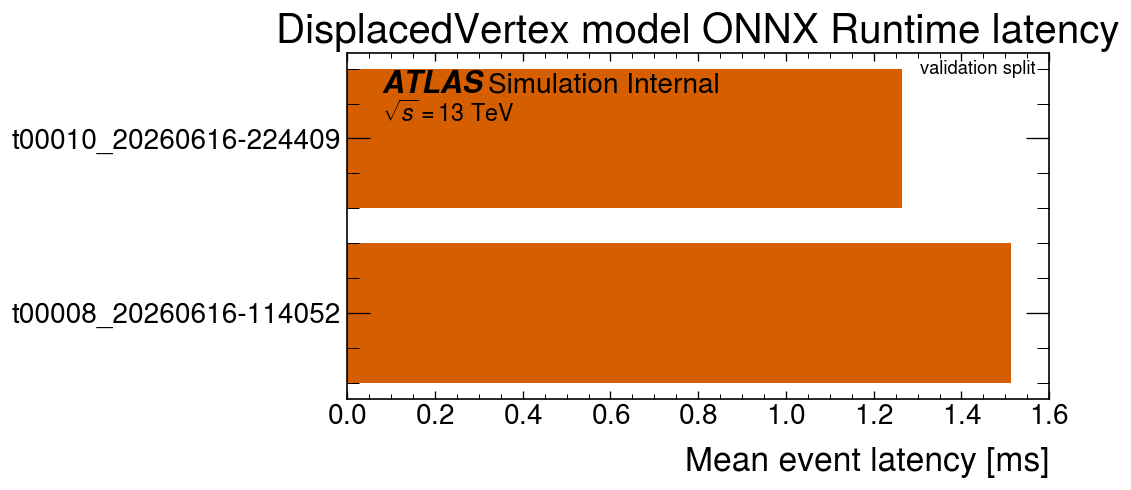

(<Figure size 1080x480 with 1 Axes>,
 <Axes: title={'center': 'DisplacedVertex model ONNX Runtime latency'}, xlabel='Mean event latency [ms]'>)

In [8]:
df = summary_plot.dropna(subset=["mean_event_latency_ms_onnxruntime"]).copy()
df = df.sort_values("mean_event_latency_ms_onnxruntime", ascending=False)
barh_plot(
    df,
    x="mean_event_latency_ms_onnxruntime",
    title="DisplacedVertex model ONNX Runtime latency",
    xlabel="Mean event latency [ms]",
    filename="latency_onnxruntime.png",
    sample_label="validation split",
)


## ROC AUC

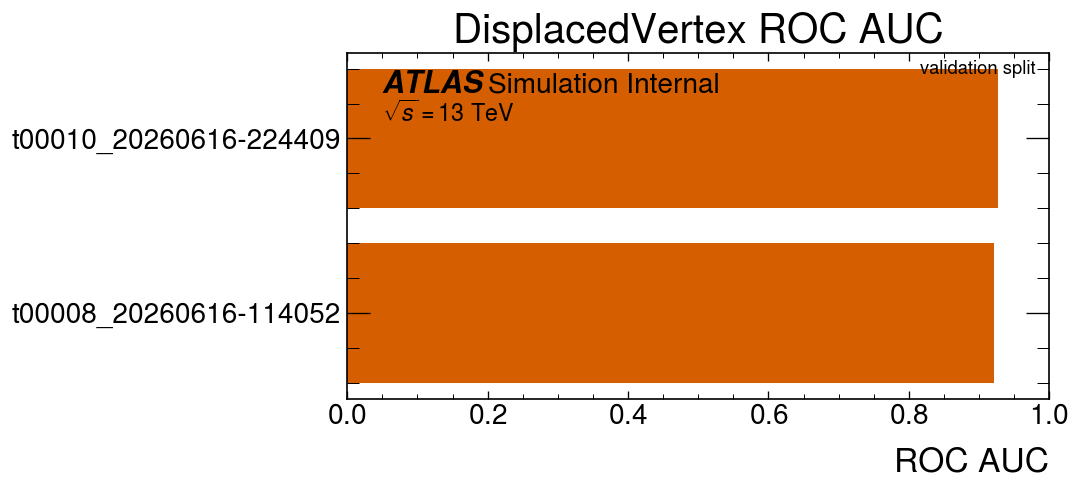

In [9]:
if "roc_auc" in summary_plot.columns:
    df = summary_plot.dropna(subset=["roc_auc"]).copy().sort_values("roc_auc", ascending=True)
    barh_plot(
        df,
        x="roc_auc",
        title="DisplacedVertex ROC AUC",
        xlabel="ROC AUC",
        filename="roc_auc.png",
        sample_label="validation split",
    )
else:
    print("No roc_auc column found in model_summary.csv")


## TPR at target FPR

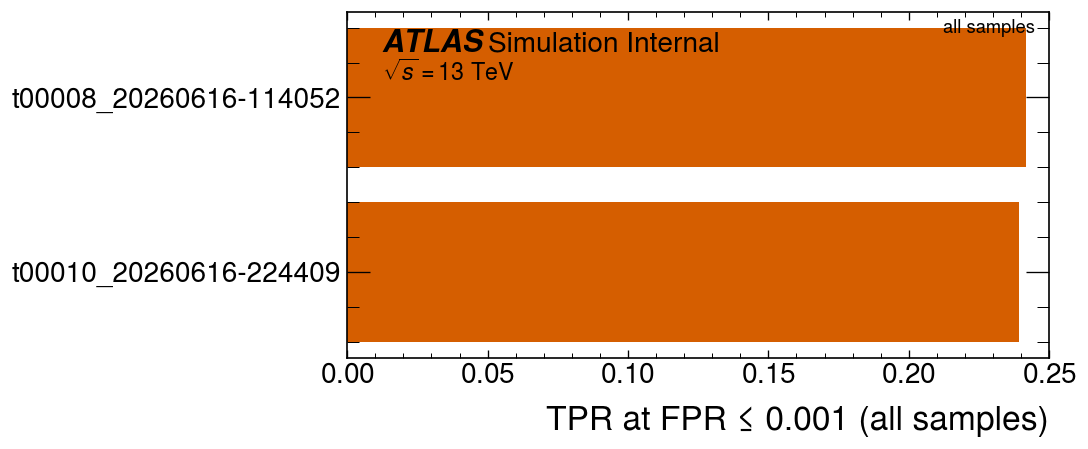

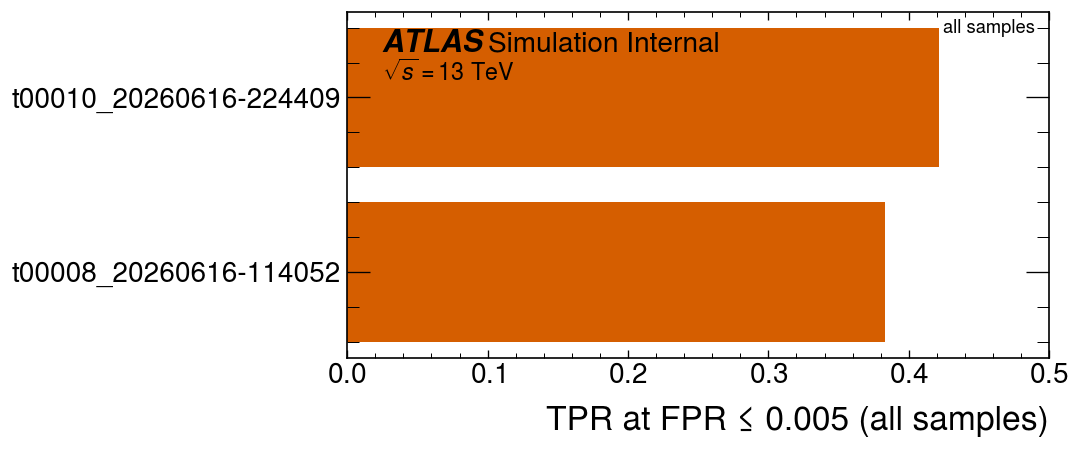

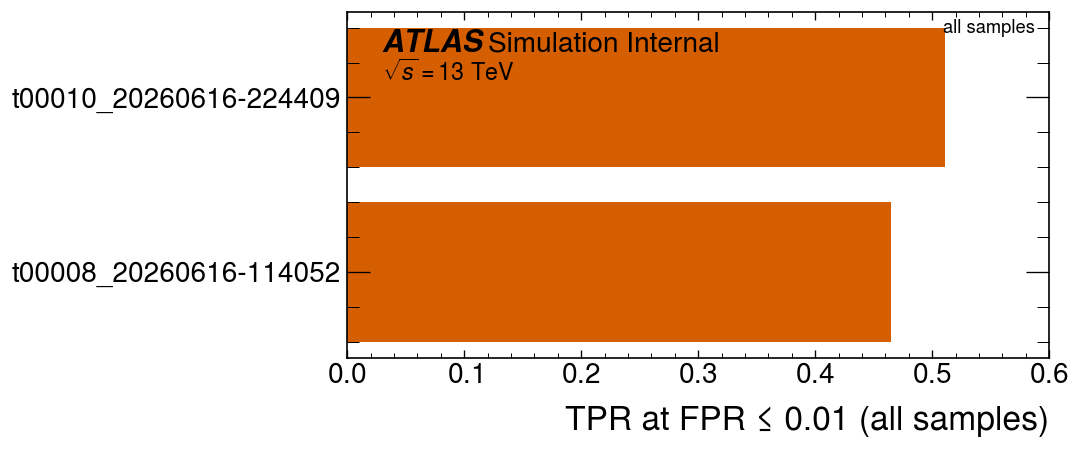

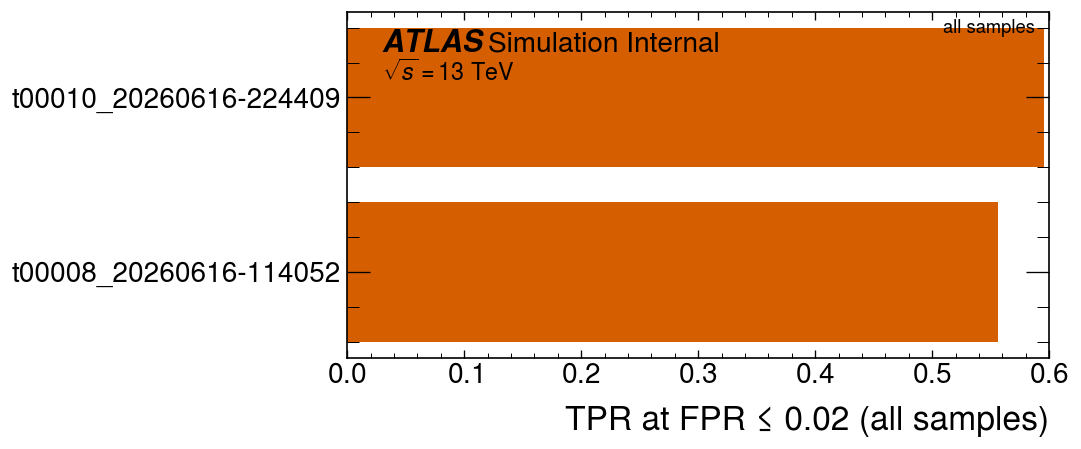

In [10]:
for target in sorted(op_fpr_sample["target_fpr"].dropna().unique()):
    df = op_fpr_sample[np.isclose(op_fpr_sample["target_fpr"], target)].copy()
    df = df.dropna(subset=["tpr"]).sort_values("tpr", ascending=True)
    barh_plot(
        df,
        x="tpr",
        title=None,
        xlabel=f"TPR at FPR ≤ {target:g} ({pretty_sample_name(TEST_SAMPLE)})",
        filename=f"tpr_at_target_fpr_{target:g}_{safe_filename(TEST_SAMPLE)}.png".replace(".", "p"),
        sample_label=pretty_sample_name(TEST_SAMPLE),
    )


## Accuracy and precision at target FPR

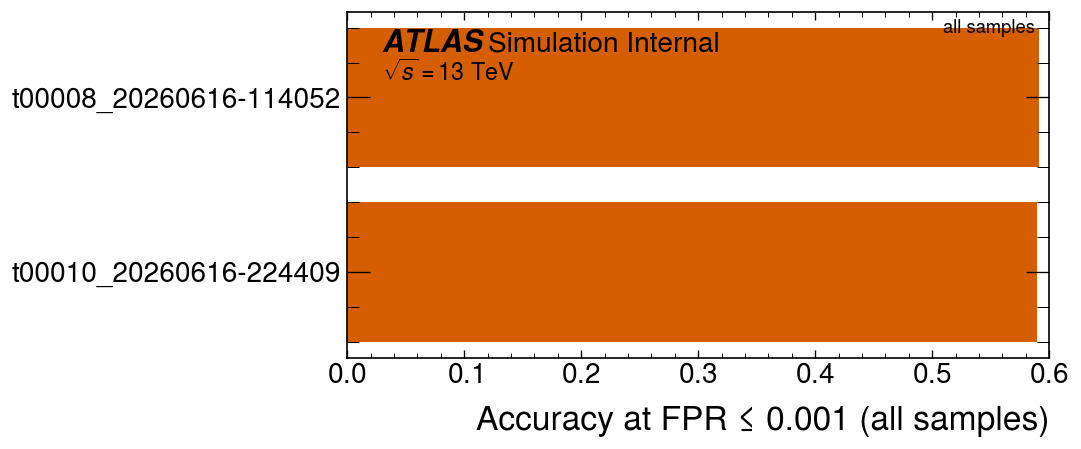

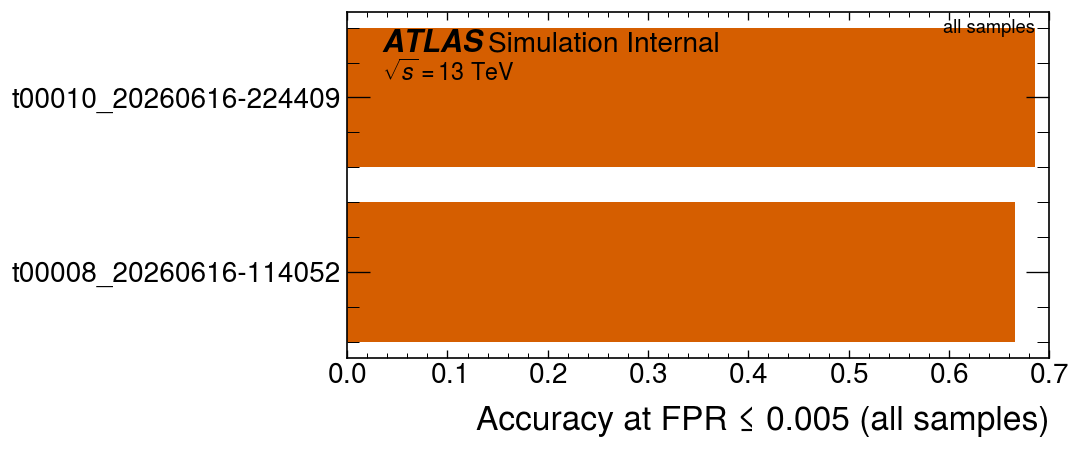

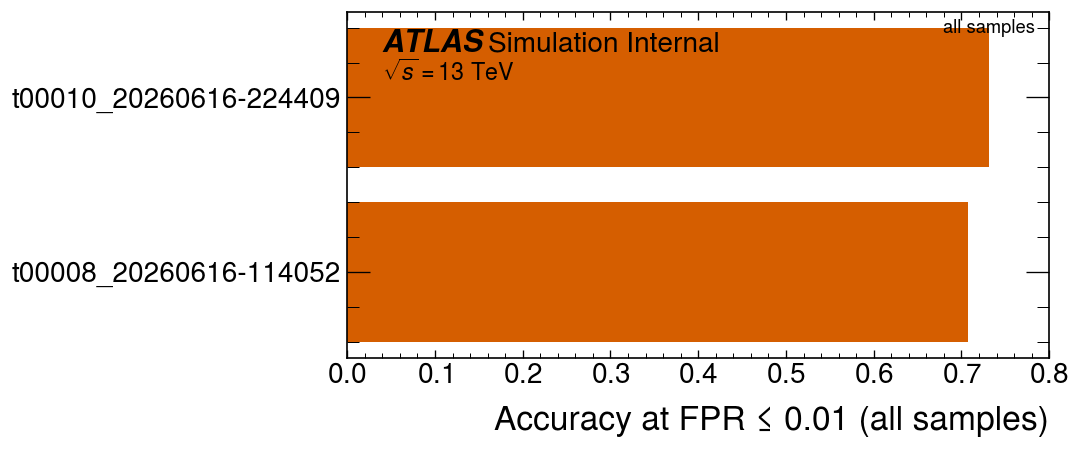

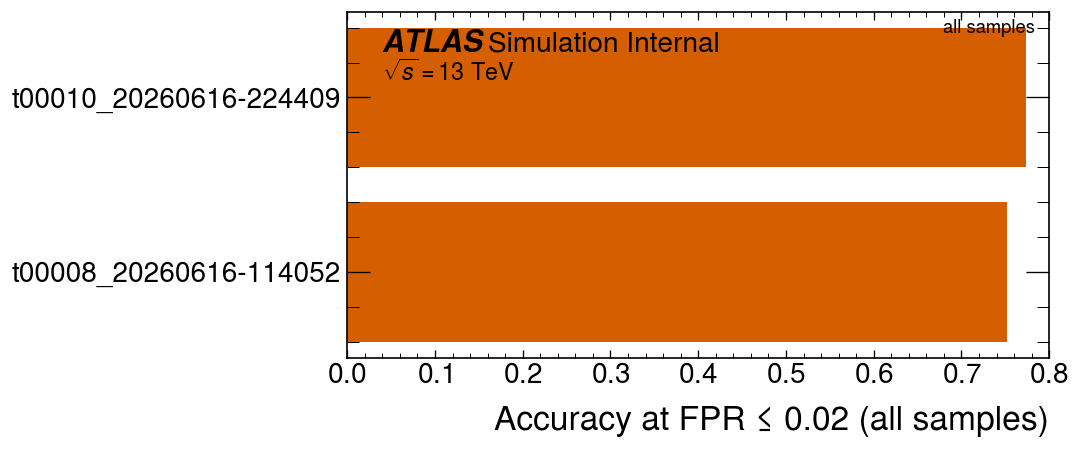

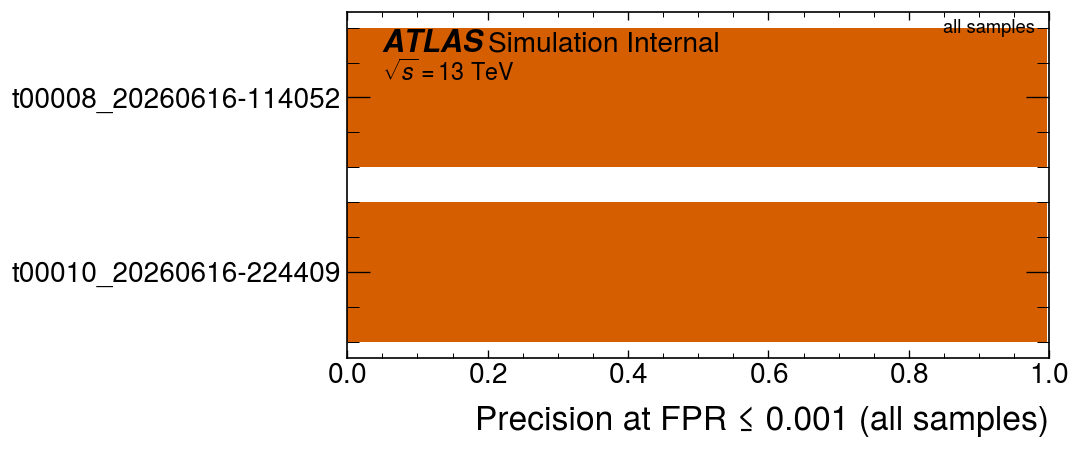

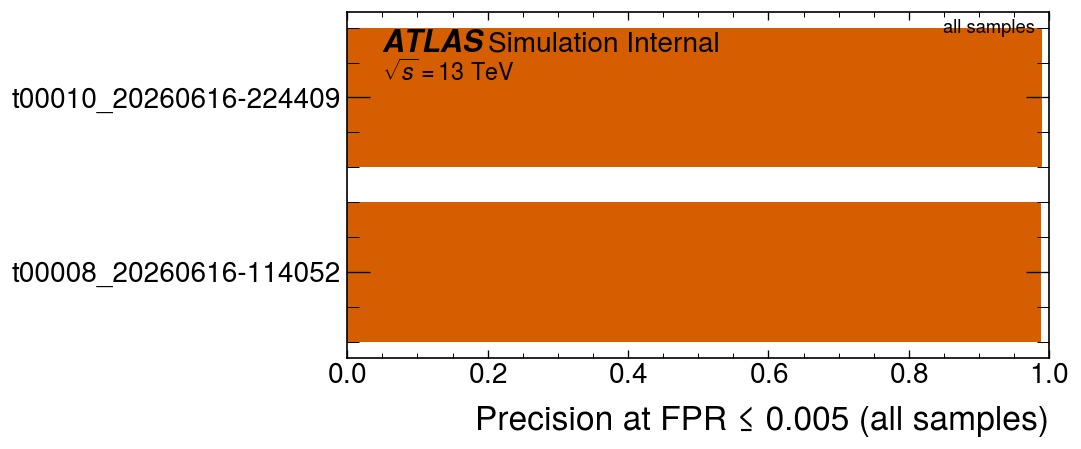

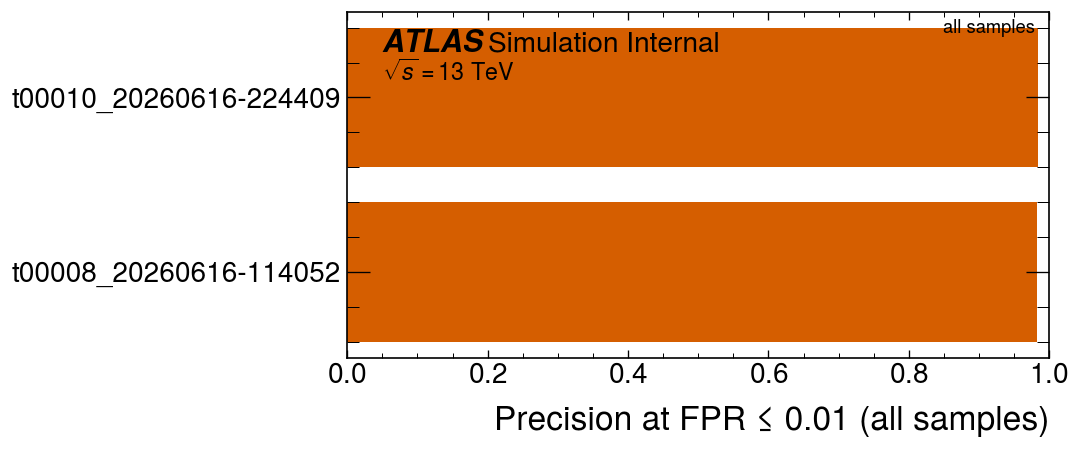

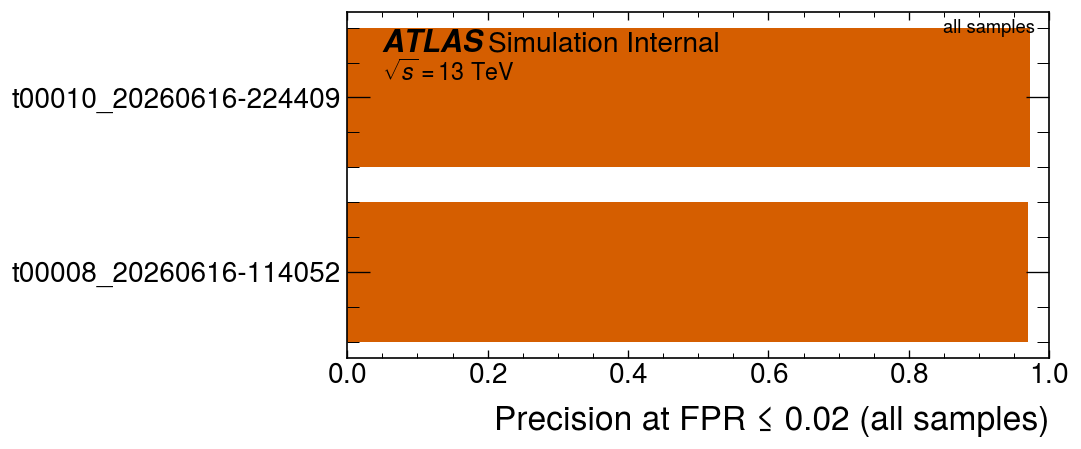

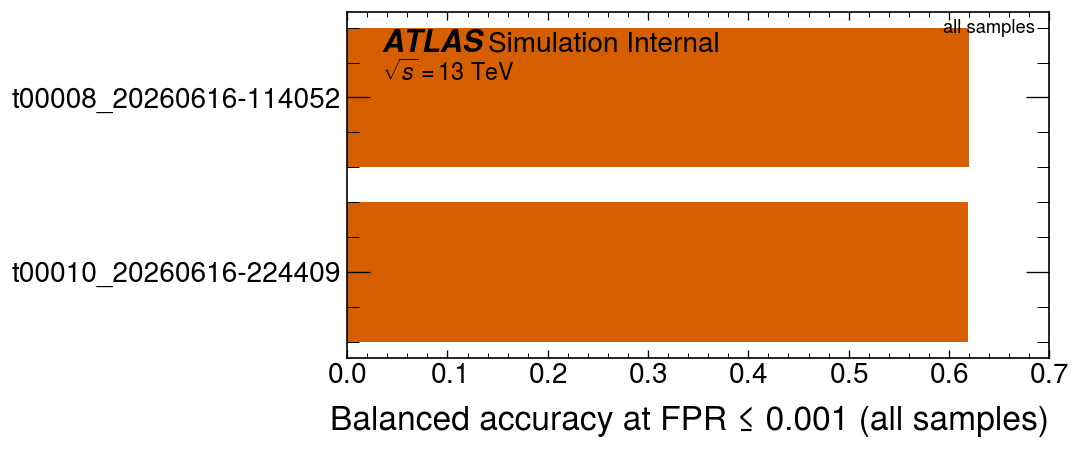

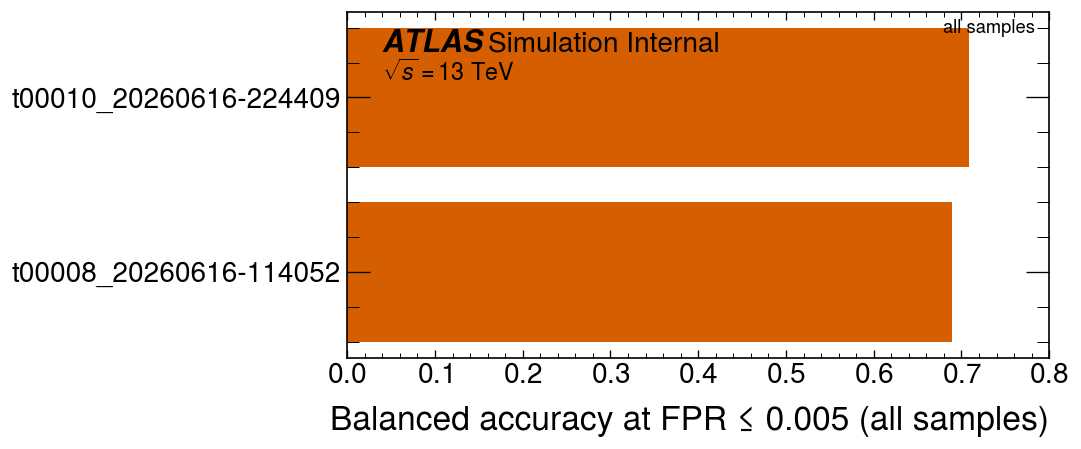

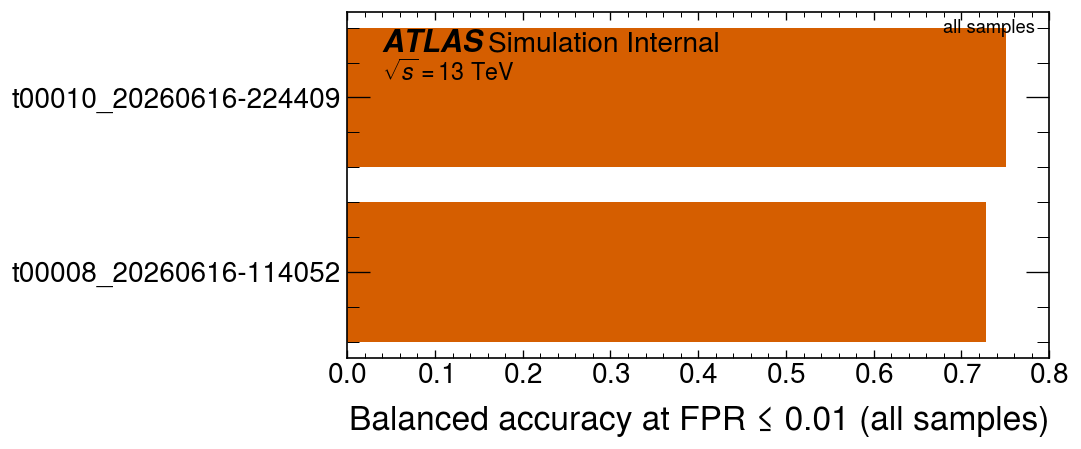

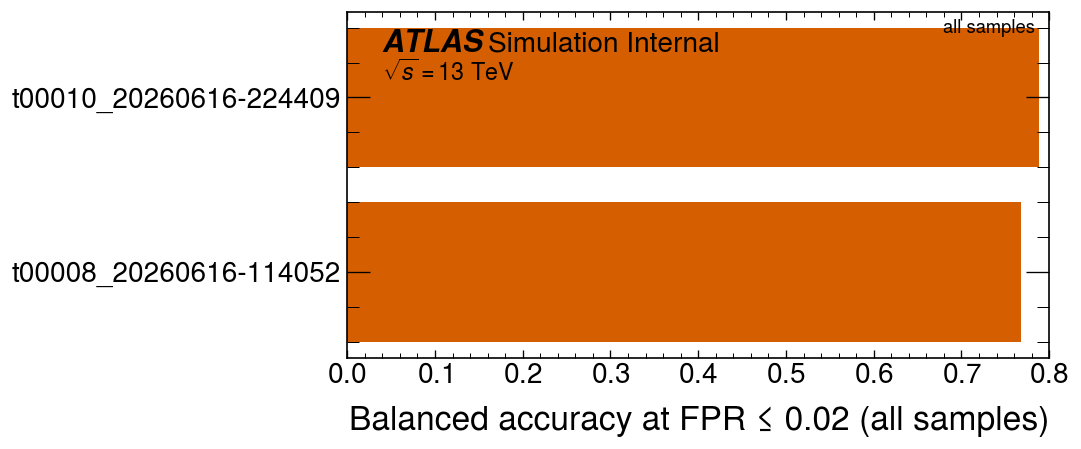

In [11]:
for metric, label in [("accuracy", "Accuracy"), ("precision", "Precision"), ("balanced_accuracy", "Balanced accuracy")]:
    if metric not in op_fpr_sample.columns:
        print(f"No {metric} column found")
        continue
    for target in sorted(op_fpr_sample["target_fpr"].dropna().unique()):
        df = op_fpr_sample[np.isclose(op_fpr_sample["target_fpr"], target)].copy()
        df = df.dropna(subset=[metric]).sort_values(metric, ascending=True)
        barh_plot(
            df,
            x=metric,
            title=None,
            xlabel=f"{label} at FPR ≤ {target:g} ({pretty_sample_name(TEST_SAMPLE)})",
            filename=f"{metric}_at_target_fpr_{target:g}_{safe_filename(TEST_SAMPLE)}.png".replace(".", "p"),
            sample_label=pretty_sample_name(TEST_SAMPLE),
        )


## Partial AUC in low-FPR region

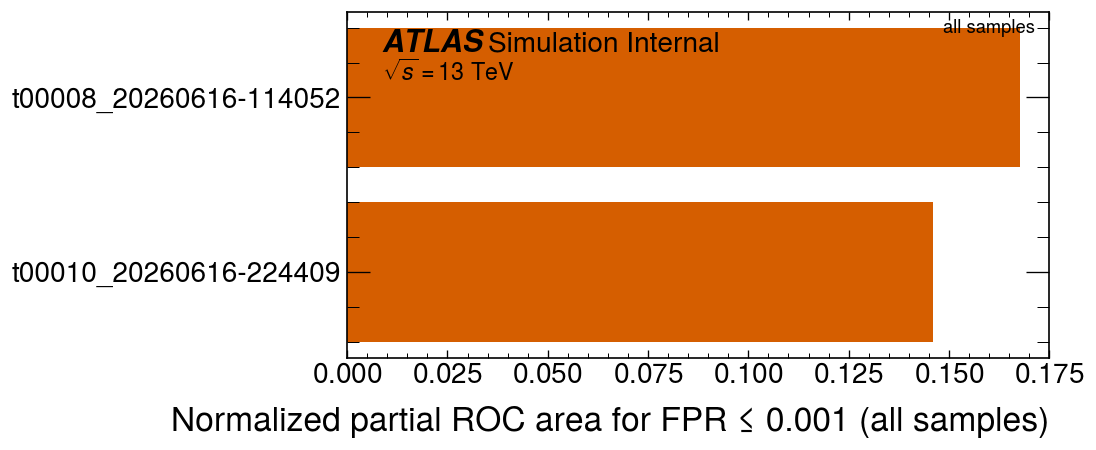

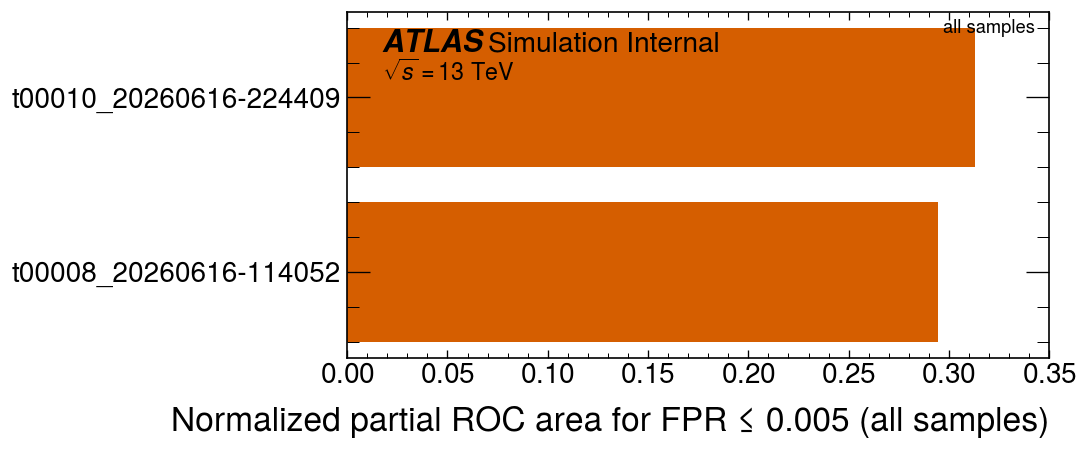

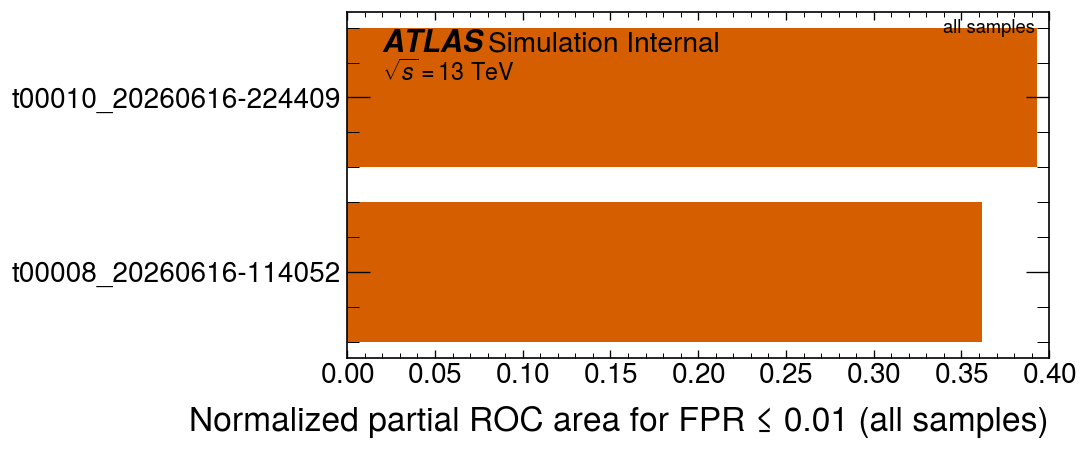

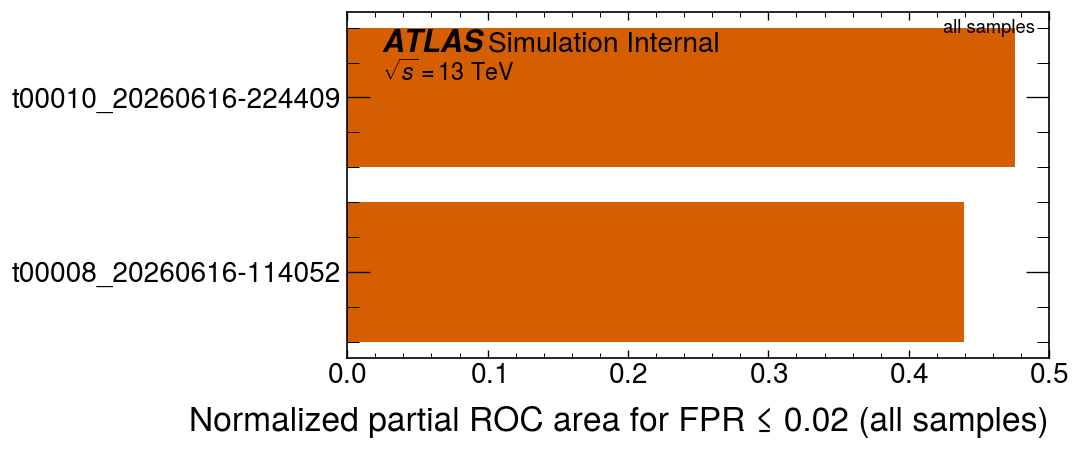

In [12]:
for fpr_max in sorted(pauc_sample["fpr_max"].dropna().unique()):
    df = pauc_sample[np.isclose(pauc_sample["fpr_max"], fpr_max)].copy()
    df = df.dropna(subset=["normalized_area"]).sort_values("normalized_area", ascending=True)
    barh_plot(
        df,
        x="normalized_area",
        title=None,
        xlabel=f"Normalized partial ROC area for FPR ≤ {fpr_max:g} ({pretty_sample_name(TEST_SAMPLE)})",
        filename=f"partial_auc_low_fpr_{fpr_max:g}_{safe_filename(TEST_SAMPLE)}.png".replace(".", "p"),
        sample_label=pretty_sample_name(TEST_SAMPLE),
    )


## Latency vs quality

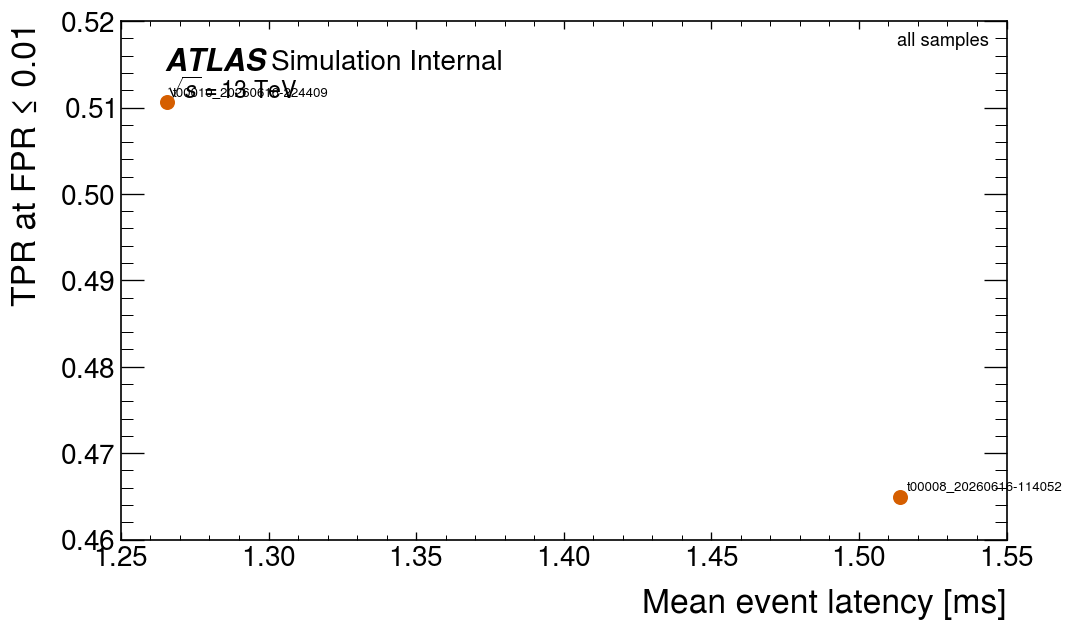

In [13]:
target_values = np.asarray(sorted(op_fpr_sample["target_fpr"].dropna().unique()), dtype=float)
if target_values.size == 0:
    raise RuntimeError("No target_fpr values found")

if np.any(np.isclose(target_values, BEST_TARGET_FPR)):
    quality_target = float(target_values[np.argmin(np.abs(target_values - BEST_TARGET_FPR))])
else:
    quality_target = float(target_values[np.argmin(np.abs(target_values - BEST_TARGET_FPR))])
    print(f"Requested BEST_TARGET_FPR={BEST_TARGET_FPR}, using closest available target_fpr={quality_target}")

quality_cols = [
    "model_id", "display_name", "plot_name", "target_fpr", "tpr", "accuracy", "precision", "threshold", "fpr",
]
quality_cols = [c for c in quality_cols if c in op_fpr_sample.columns]
quality = op_fpr_sample[np.isclose(op_fpr_sample["target_fpr"], quality_target)][quality_cols].copy()
df = summary_plot.merge(quality, on=["model_id", "display_name", "plot_name"], how="inner")
df = df.dropna(subset=["mean_event_latency_ms_onnxruntime", "tpr"])

with plot_context():
    fig, ax = plt.subplots(figsize=(9, 6), dpi=120)
    ax.scatter(df["mean_event_latency_ms_onnxruntime"], df["tpr"])
    for _, row in df.iterrows():
        ax.annotate(row["plot_name"], (row["mean_event_latency_ms_onnxruntime"], row["tpr"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("Mean event latency [ms]")
    ax.set_ylabel(f"TPR at FPR ≤ {quality_target:g}")
    atlas_header(ax, sample_label=pretty_sample_name(TEST_SAMPLE))
    fig.subplots_adjust(left=0.14, right=0.96, bottom=0.14, top=0.86)
    save_current_figure(f"latency_vs_tpr_target_fpr_{quality_target:g}_{safe_filename(TEST_SAMPLE)}.png".replace(".", "p"))


## ROC curves from `plot_payload.pkl`

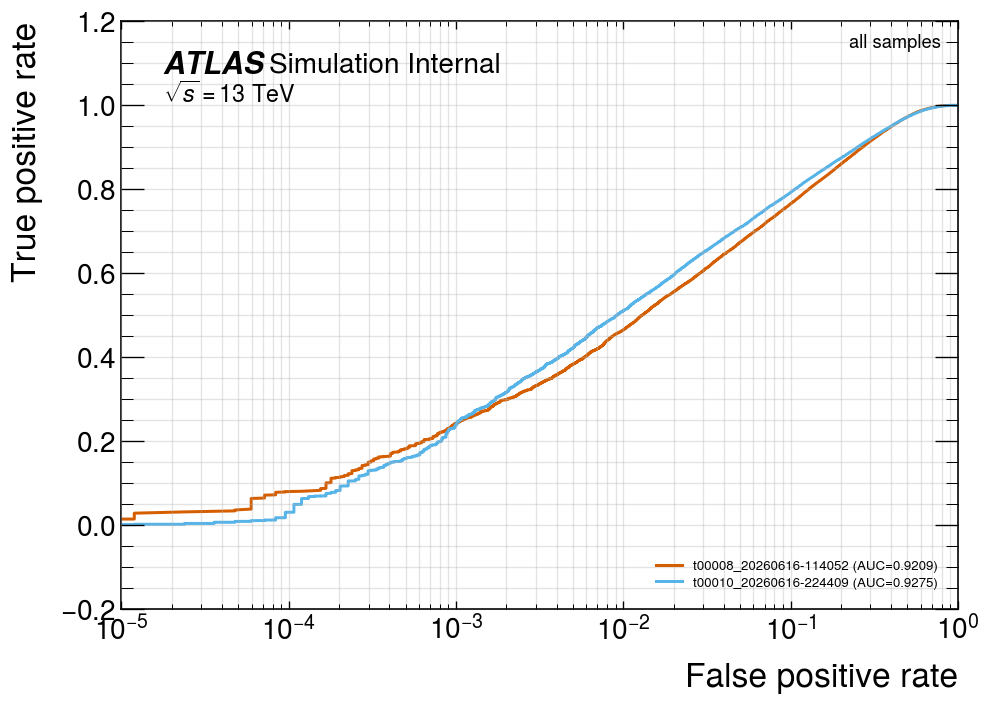

(<Figure size 1020x816 with 1 Axes>,
 <Axes: xlabel='False positive rate', ylabel='True positive rate'>)

In [14]:
def plot_payload_roc(entries, sample="__all__", xmode="fpr", title=None, filename=None, figsize=(8.5, 6.8), dpi=120):
    entries = sorted_entries(entries_with_sample(entries, sample))
    if not entries:
        print(f"No entries have sample={sample!r}")
        return None, None
    with plot_context():
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        for entry in entries:
            roc = entry.get("samples", {}).get(sample, {}).get("roc", {})
            fpr = np.asarray(roc.get("fpr", []), dtype=float)
            tpr = np.asarray(roc.get("tpr", []), dtype=float)
            if fpr.size == 0 or tpr.size == 0:
                continue
            x = fpr if xmode == "fpr" else 1.0 - fpr
            label = f"{entry.get('plot_name', entry.get('display_name'))} (AUC={roc.get('auc', np.nan):.4f})"
            ax.plot(x, tpr, label=label, linewidth=1.8)
        if xmode == "fpr":
            ax.set_xlabel("False positive rate")
            ax.set_xscale("log")
            ax.set_xlim(left=max(1e-6, ax.get_xlim()[0]), right=1.0)
        else:
            ax.set_xlabel("Background rejection = 1 - FPR")
            ax.set_xlim(0.0, 1.0)
        ax.set_ylabel("True positive rate")
        if title:
            ax.set_title(title)
        atlas_header(ax, sample_label=pretty_sample_name(sample))
        ax.grid(True, which="both", alpha=0.35)
        ax.legend(fontsize=8, loc="lower right")
        fig.subplots_adjust(left=0.14, right=0.96, bottom=0.14, top=0.86)
        if filename:
            save_current_figure(filename)
        return fig, ax

plot_payload_roc(
    plot_entries,
    sample=TEST_SAMPLE,
    xmode="fpr",
    title=None,
    filename=f"roc_{safe_filename(TEST_SAMPLE)}.png",
)


## Final ranking table

In [15]:
target_values = np.asarray(sorted(op_fpr_sample["target_fpr"].dropna().unique()), dtype=float)
best_target = float(target_values[np.argmin(np.abs(target_values - BEST_TARGET_FPR))])

best_op_cols = [
    "model_id", "threshold", "accuracy", "balanced_accuracy", "tpr", "fpr", "background_rejection", "precision", "f1", "target_fpr", "sample",
]
best_op_cols = [c for c in best_op_cols if c in op_fpr_sample.columns]
best_op = op_fpr_sample[np.isclose(op_fpr_sample["target_fpr"], best_target)][best_op_cols].copy()
table = summary_plot.merge(best_op, on="model_id", how="left")

cols = [
    "plot_name", "metrics_source", "sample", "num_validation_events", "num_signal_events", "num_background_events",
    "roc_auc", "mean_event_latency_ms_onnxruntime", "tpr", "fpr", "accuracy", "balanced_accuracy", "precision", "f1",
    "threshold", "onnx_model_size_mb", "providers", "onnx_path",
]
cols = [c for c in cols if c in table.columns]

sort_cols, ascending = [], []
if "tpr" in table.columns:
    sort_cols.append("tpr"); ascending.append(False)
if "mean_event_latency_ms_onnxruntime" in table.columns:
    sort_cols.append("mean_event_latency_ms_onnxruntime"); ascending.append(True)
if sort_cols:
    table = table.sort_values(sort_cols, ascending=ascending)

display(table[cols])


,plot_name,metrics_source,sample,num_validation_events,num_signal_events,num_background_events,roc_auc,mean_event_latency_ms_onnxruntime,tpr,fpr,accuracy,balanced_accuracy,precision,f1,threshold,onnx_model_size_mb,providers,onnx_path
1,t00010_20260616-224409,onnxruntime_hist,__all__,181640,97840,83800,0.927519,1.265482,0.510589,0.01,0.731766,0.750294,0.983502,0.672202,0.60959,5.584156,"CUDAExecutionProvider,CPUExecutionProvider",/eos/project-i01/f/fcc-ml/ddicroce/ATLAS_MuonS...
0,t00008_20260616-114052,onnxruntime_hist,__all__,181640,97840,83800,0.920932,1.513839,0.464943,0.01,0.707179,0.727471,0.981912,0.631069,0.94730,7.278724,"CUDAExecutionProvider,CPUExecutionProvider",/eos/project-i01/f/fcc-ml/ddicroce/ATLAS_MuonS...


## Parity summary, if available

In [16]:
if parity.empty:
    print("No parity file found.")
else:
    display_cols = [
        "plot_name", "mean_event_latency_ms_pytorch", "mean_event_latency_ms_onnxruntime",
        "max_abs_prob_diff_pytorch_vs_ort", "mean_abs_prob_diff_pytorch_vs_ort", "labels_match", "parity_error",
    ]
    display_cols = [c for c in display_cols if c in parity.columns]
    display(parity[display_cols])


No parity file found.


## Best model and per-sample row-normalized percentage confusion matrices


Available samples in best_entry['samples']:
  - __all__
  - displacedVtx_mu200
  - vertex_JPSI_mu200
  - vertex_Zmumu_mu200
  - vertex_a_mumu_m100_ctau5000_mu200
  - vertex_a_mumu_m10_ctau500_mu200
  - vertex_a_mumu_m20_ctau500_mu200
  - vertex_a_mumu_m2_ctau100_mu200
  - vertex_a_mumu_m4_ctau100_mu200
  - vertex_a_mumu_m50_ctau1000_mu200
  - vertex_a_mumu_m6_ctau100_mu200
  - vertex_a_mumu_m8_ctau500_mu200
  - vertex_jj_mu200
  - vertex_ttbar_mu200
Missing requested samples in plot_payload.pkl for this best model:
  - vertex_Haa4mu_m10_ctau500_mu200
  - vertex_Haa4mu_m4_ctau200_mu200
  - vertex_Haa4mu_m6_ctau200_mu200
  - vertex_Haa4mu_m8_ctau500_mu200
These plots require the inference payload to contain per-sample histograms.
Best model: t00010_20260616-224409
Best-model samples to plot: __all__, vertex_a_mumu_m100_ctau5000_mu200, vertex_a_mumu_m10_ctau500_mu200, vertex_a_mumu_m20_ctau500_mu200, vertex_a_mumu_m2_ctau100_mu200, vertex_a_mumu_m4_ctau100_mu200, vertex_a_mumu_m50_ctau100

,threshold,threshold_bin,accuracy,balanced_accuracy,tpr,recall,signal_efficiency,signal_loss,fpr,background_rejection,precision,f1,tn,fp,fn,tp,target_fpr,model_id,display_name,plot_name,run_group,layer_type,sample,mean_event_latency_ms_onnxruntime
1,0.60959,121918,0.731766,0.750294,0.510589,0.510589,0.510589,0.489411,0.01,0.99,0.983502,0.672202,82962,838,47884,49956,0.01,/eos/project-i01/f/fcc-ml/ddicroce/ATLAS_MuonS...,trial00010_20260616-224409,t00010_20260616-224409,models,edge_residual,__all__,1.265482


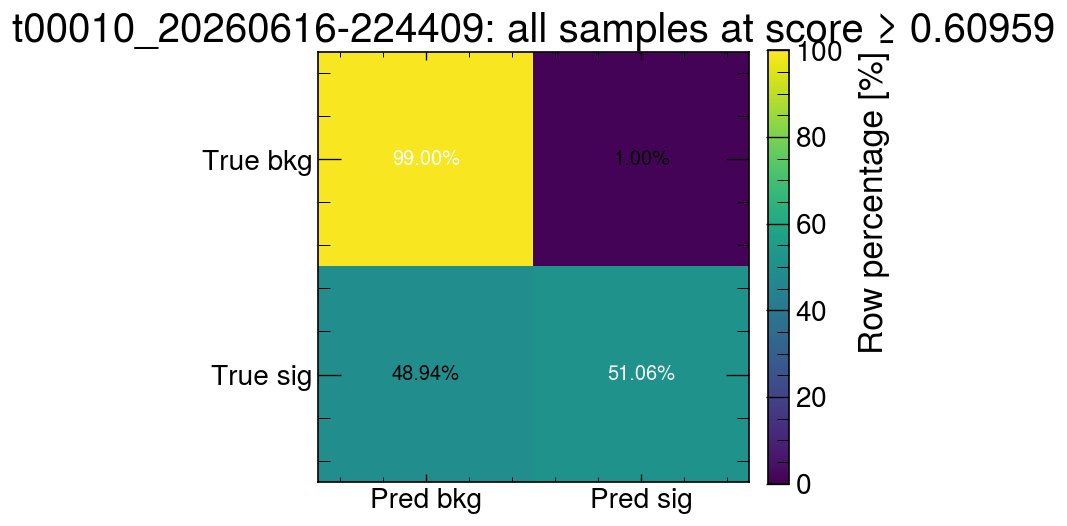

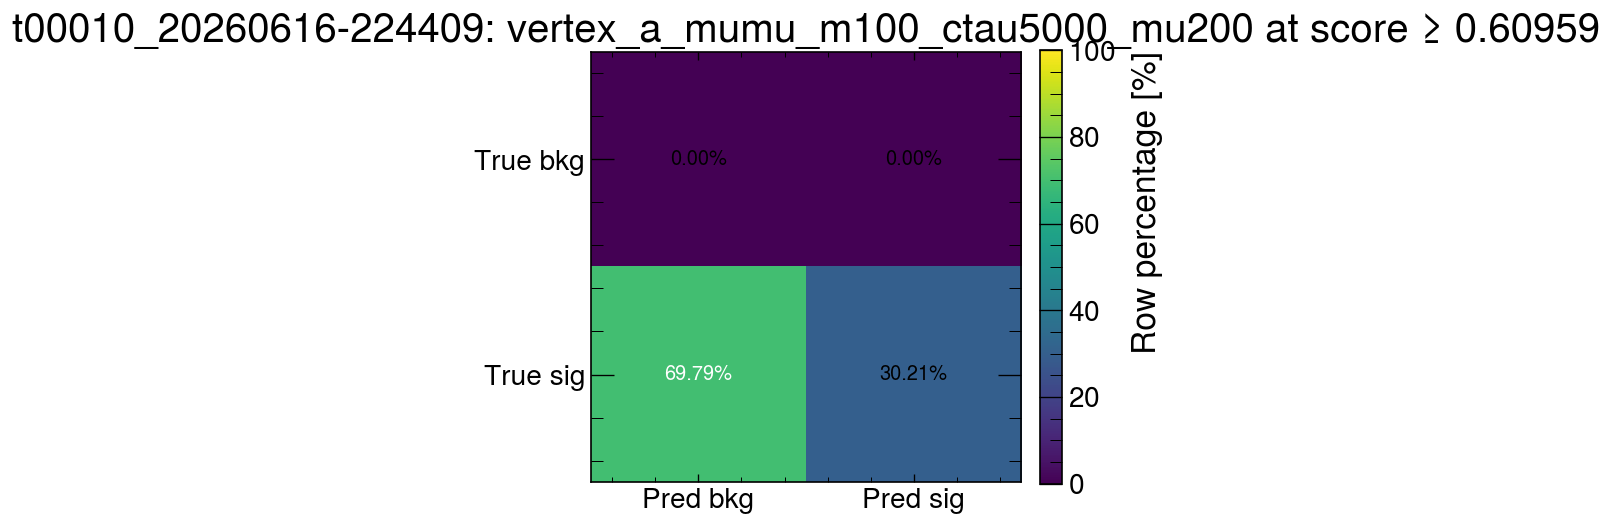

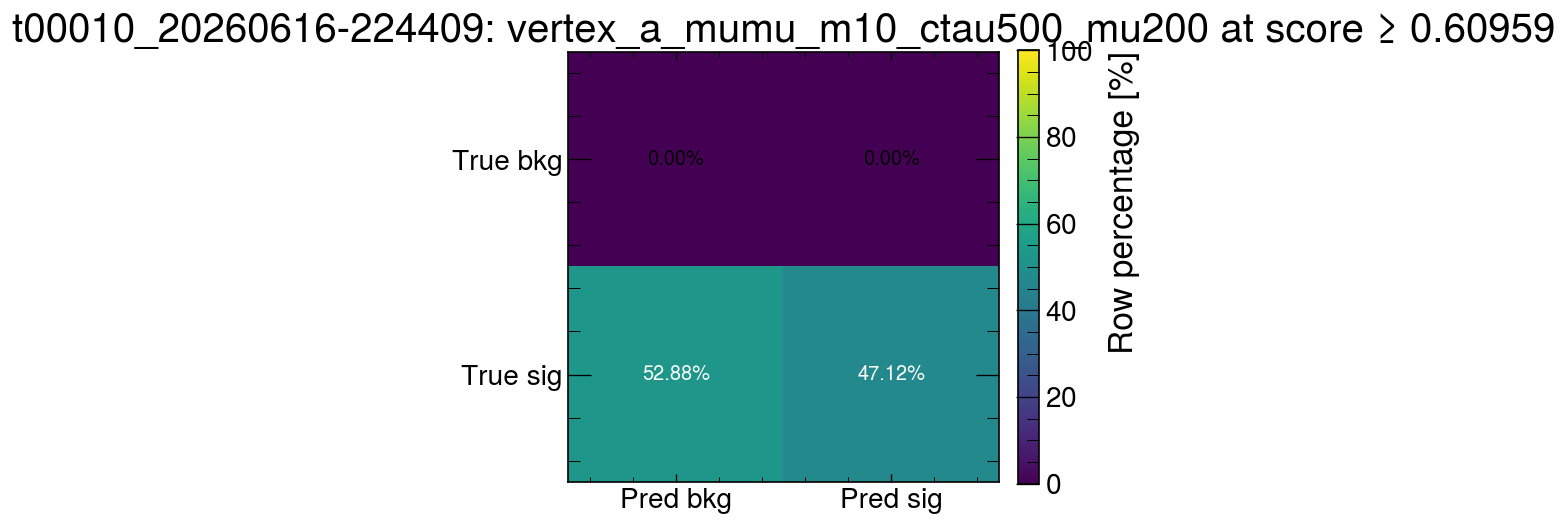

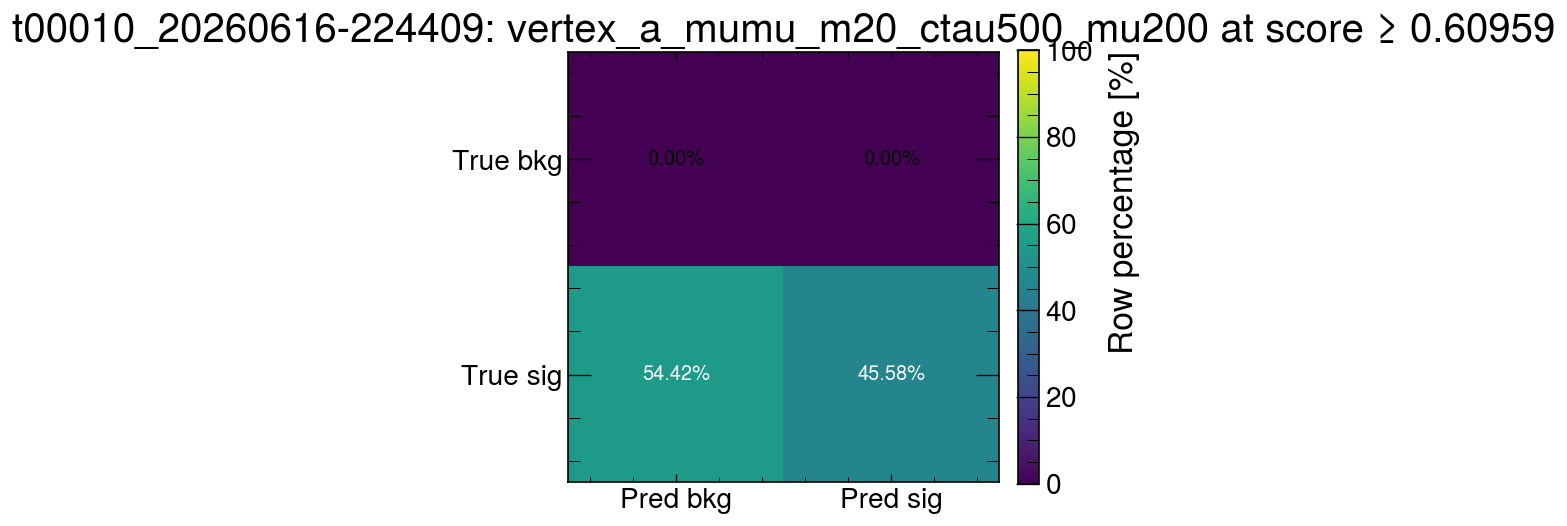

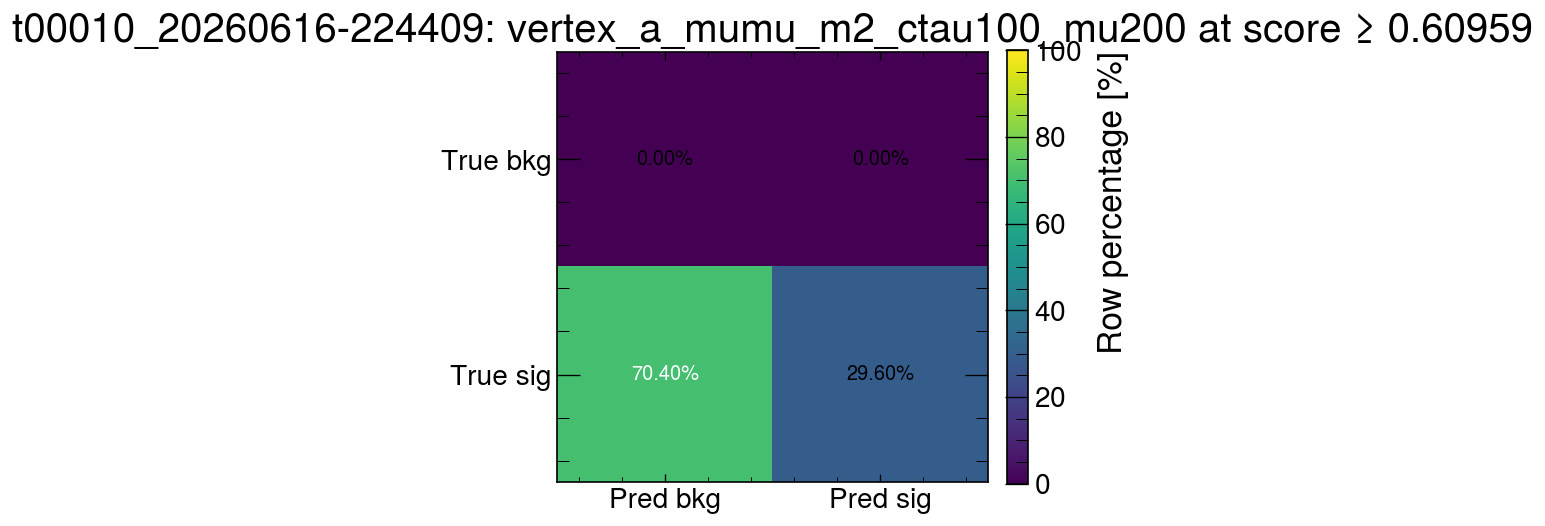

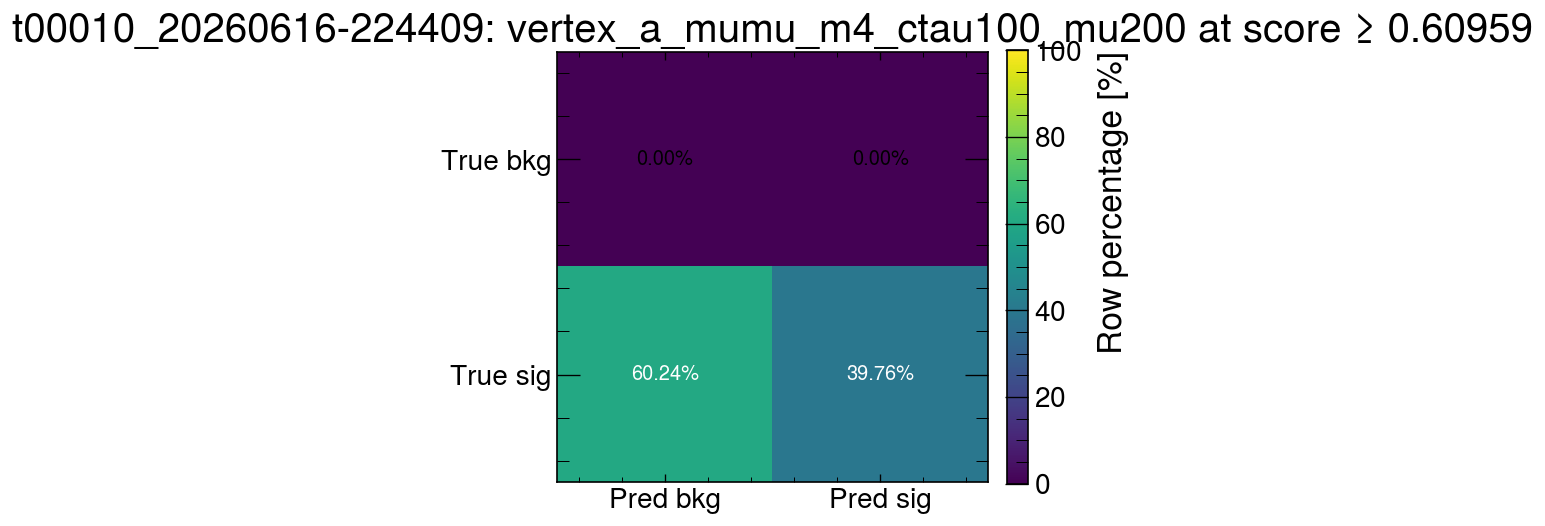

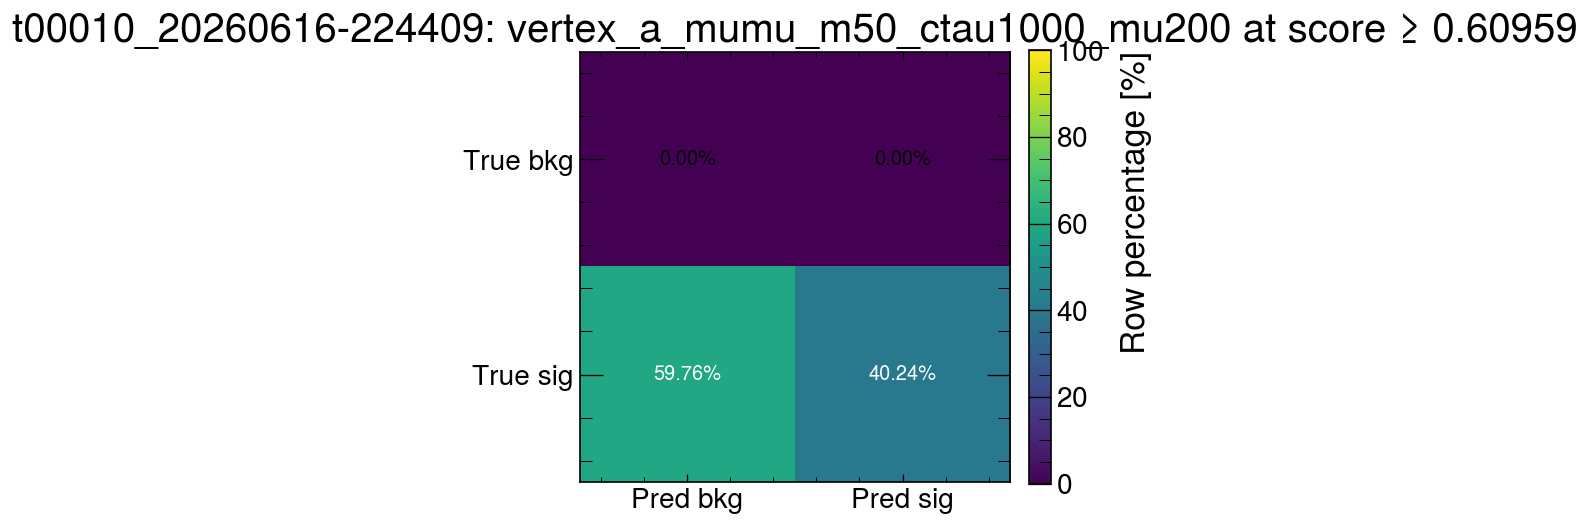

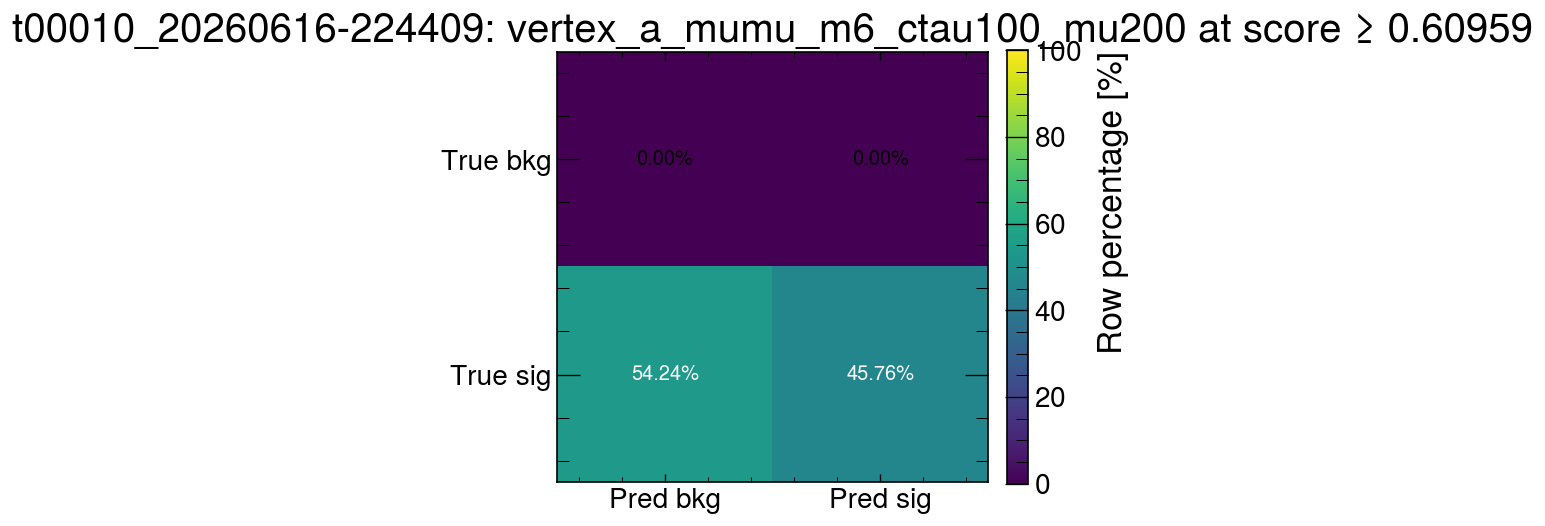

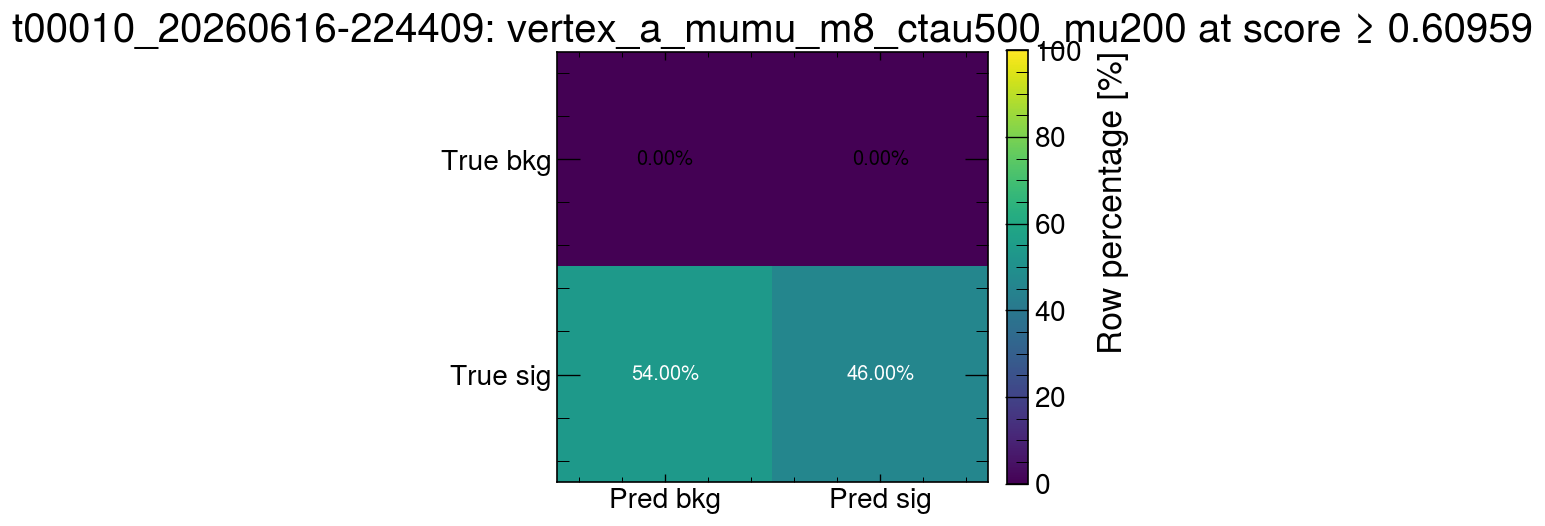

In [17]:
best_candidates = op_fpr_sample[np.isclose(op_fpr_sample["target_fpr"], best_target)].copy()
if EXCLUDE_REFERENCE_FOR_BEST and "run_group" in best_candidates.columns:
    best_candidates = best_candidates[best_candidates["run_group"] != "reference"].copy()

best_candidates = best_candidates.dropna(subset=["tpr", "threshold"])
if best_candidates.empty:
    raise RuntimeError(f"No candidates with finite TPR and threshold at target_fpr={best_target}")

lat_cols = ["model_id", "mean_event_latency_ms_onnxruntime"]
lat = summary_plot[lat_cols].copy() if all(c in summary_plot.columns for c in lat_cols) else pd.DataFrame()
if not lat.empty:
    best_candidates = best_candidates.merge(lat, on="model_id", how="left")

sort_cols, ascending = ["tpr"], [False]
if "mean_event_latency_ms_onnxruntime" in best_candidates.columns:
    sort_cols.append("mean_event_latency_ms_onnxruntime")
    ascending.append(True)
best_row = best_candidates.sort_values(sort_cols, ascending=ascending).iloc[0]
best_model_id = best_row["model_id"]
best_entry = next(entry for entry in plot_entries if entry.get("model_id") == best_model_id)
best_name = best_entry.get("plot_name", best_entry.get("display_name", best_model_id))

available_best_samples = list(best_entry.get("samples", {}).keys())
print("Available samples in best_entry['samples']:")
for s in available_best_samples:
    print("  -", s)

best_detail_samples = ordered_samples_for_best_model(
    best_entry,
    plot_payload.get("best_model_detail_samples", SIGNAL_SAMPLE_NAMES),
    include_all=True,
)

print("Best model:", best_name)
print("Best-model samples to plot:", ", ".join(best_detail_samples))
display(pd.DataFrame([best_row]))


def plot_confusion_matrix(cm, title, filename=None, normalize="row"):
    """Plot a 2x2 confusion matrix.

    By default this matches the Bucket notebook logic: normalize each true-label
    row, then display the normalized values. Here the labels are formatted as
    percentages, so each true-class row sums to 100%.
    """
    cm_counts = np.asarray(cm, dtype=float)

    if normalize == "row":
        row_sums = cm_counts.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm_plot = 100.0 * cm_counts / row_sums
        annotate_fmt = "{:.2f}%"
        colorbar_label = "Row percentage [%]"
        vmin, vmax = 0.0, 100.0
    elif normalize == "all":
        total = cm_counts.sum()
        cm_plot = 100.0 * cm_counts / (total if total else 1.0)
        annotate_fmt = "{:.2f}%"
        colorbar_label = "Total percentage [%]"
        vmin, vmax = 0.0, 100.0
    elif normalize is None:
        cm_plot = cm_counts
        annotate_fmt = "{:.0f}"
        colorbar_label = "Events"
        vmin, vmax = None, None
    else:
        raise ValueError("normalize must be 'row', 'all', or None")

    with plot_context():
        fig, ax = plt.subplots(figsize=(5.8, 5.0), dpi=120)
        im = ax.imshow(cm_plot, interpolation="nearest", cmap="Blues", vmin=vmin, vmax=vmax)
        ax.set_xticks([0, 1], labels=["Predicted background", "Predicted signal"])
        ax.set_yticks([0, 1], labels=["True background", "True signal"])
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("True class")

        max_val = np.nanmax(cm_plot) if np.size(cm_plot) else 1.0
        if not np.isfinite(max_val) or max_val <= 0:
            max_val = 1.0

        for i in range(cm_plot.shape[0]):
            for j in range(cm_plot.shape[1]):
                value = cm_plot[i, j]
                color = "white" if value > 0.5 * max_val else "black"
                ax.text(
                    j,
                    i,
                    annotate_fmt.format(value),
                    ha="center",
                    va="center",
                    color=color,
                    fontsize=14,
                    fontweight="semibold",
                )

        ax.set_title(title)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(colorbar_label)
        fig.tight_layout()
        save_current_figure(filename)
        return fig, ax


# Plot row-normalized percentage confusion matrix at the chosen target-FPR
key = operating_point_key("target_fpr", best_target)
global_threshold = float(best_row.get("threshold", np.nan))
for sample in best_detail_samples:
    sample_payload = best_entry.get("samples", {}).get(sample, {})
    cm = None
    if sample_payload and np.isfinite(global_threshold):
        cm = confusion_matrix_from_hist_payload(sample_payload, global_threshold)
    if cm is None:
        cm = sample_payload.get("confusion_matrices", {}).get(key)
    if cm is None:
        print(f"No confusion matrix found for sample={sample!r} at target_fpr={best_target:g}")
        continue
    plot_confusion_matrix(
        cm,
        title=f"{best_name}: {pretty_sample_name(sample)} at score ≥ {global_threshold:.5f}",
        filename=f"confusion_percent_{safe_filename(best_name)}_{safe_filename(sample)}_threshold_{str(f'{global_threshold:.5f}').replace('.', 'p')}.png",
        normalize="row",
    )


## Validation-only signal efficiency by signal sample

For each signal sample, this uses the threshold selected on the merged validation sample (`__all__`) at the chosen target FPR, then plots the fraction of validation signal events passing that threshold.


,sample_label,signal_efficiency_percent,num_pass_signal_events,num_signal_events,global_threshold,global_fpr,target_fpr
48,vertex_a_mumu_m100_ctau5000_mu200,30.212014,2565,8490,0.60959,0.01,0.01
49,vertex_a_mumu_m10_ctau500_mu200,47.123977,3744,7945,0.60959,0.01,0.01
50,vertex_a_mumu_m20_ctau500_mu200,45.581851,3255,7141,0.60959,0.01,0.01
51,vertex_a_mumu_m2_ctau100_mu200,29.602978,2386,8060,0.60959,0.01,0.01
52,vertex_a_mumu_m4_ctau100_mu200,39.763211,2754,6926,0.60959,0.01,0.01
53,vertex_a_mumu_m50_ctau1000_mu200,40.235988,2728,6780,0.60959,0.01,0.01
54,vertex_a_mumu_m6_ctau100_mu200,45.758108,2864,6259,0.60959,0.01,0.01
55,vertex_a_mumu_m8_ctau500_mu200,46.003706,3724,8095,0.60959,0.01,0.01


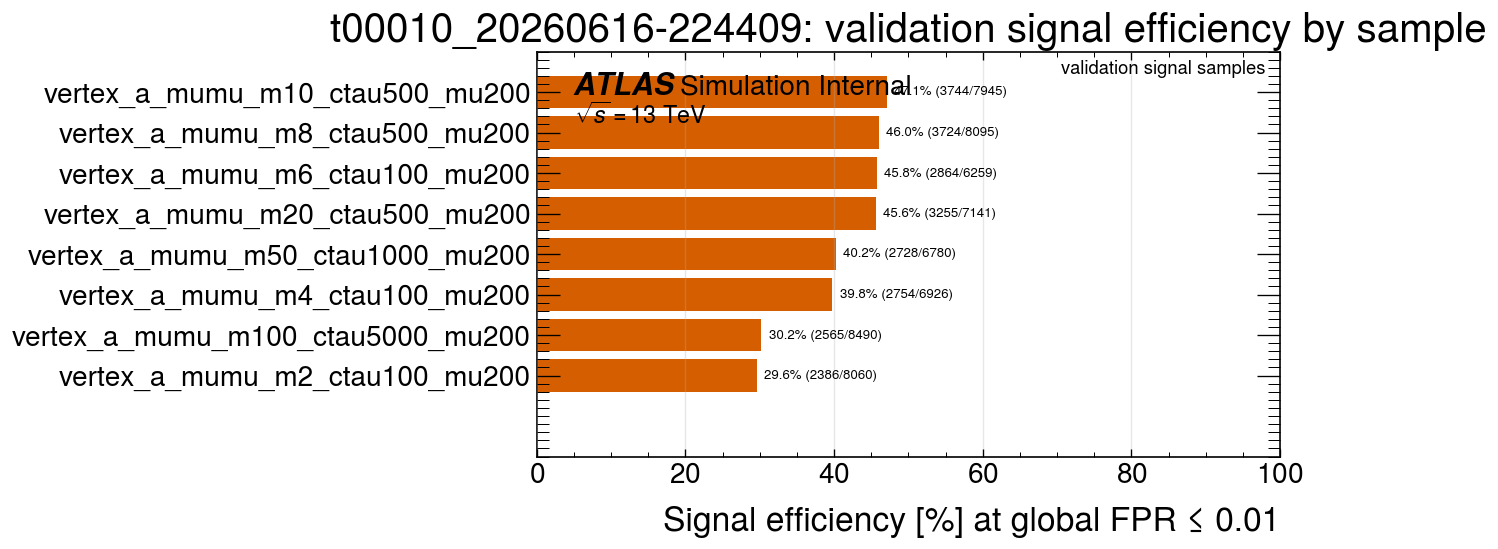

In [18]:
# Bar plot for the best model: signal efficiency for every requested signal sample.
if signal_eff_by_sample.empty:
    print("No signal-efficiency table available. Re-run the inference script with the updated version, or ensure plot_payload.pkl contains per-sample histograms.")
else:
    sig_df = signal_eff_by_sample[
        (signal_eff_by_sample["model_id"] == best_model_id)
        & np.isclose(pd.to_numeric(signal_eff_by_sample["target_fpr"], errors="coerce"), best_target)
    ].copy()

    if not sig_df.empty:
        # Keep configured signal order where possible.
        order = {sample: i for i, sample in enumerate(plot_payload.get("signal_samples", SIGNAL_SAMPLE_NAMES))}
        sig_df["_order"] = sig_df["sample"].map(order).fillna(10_000).astype(int)
        sig_df = sig_df.sort_values(["_order", "sample"]).drop(columns=["_order"])

        display_cols = [
            "sample_label", "signal_efficiency_percent", "num_pass_signal_events", "num_signal_events",
            "global_threshold", "global_fpr", "target_fpr",
        ]
        display_cols = [c for c in display_cols if c in sig_df.columns]
        display(sig_df[display_cols])

        plot_signal_efficiency_by_sample(
            sig_df,
            target_fpr=best_target,
            title=f"{best_name}: validation signal efficiency by sample",
            filename=f"signal_efficiency_by_sample_{safe_filename(best_name)}_target_fpr_{str(f'{best_target:g}').replace('.', 'p')}.png",
        )
    else:
        available = signal_eff_by_sample[["model_id", "plot_name", "target_fpr"]].drop_duplicates() if {"model_id", "plot_name", "target_fpr"}.issubset(signal_eff_by_sample.columns) else signal_eff_by_sample.head()
        print(f"No signal-efficiency rows found for best_model_id={best_model_id!r} at target_fpr={best_target:g}.")
        display(available)


## Presentation selection-efficiency table

This table applies the single threshold selected on the merged validation sample at the requested target FPR to every signal and background sample.

In [ ]:
from matplotlib.patches import Rectangle

sample_specs = [
    ("signal", "a_mumu", 2, 100, "vertex_a_mumu_m2_ctau100_mu200"),
    ("signal", "a_mumu", 4, 100, "vertex_a_mumu_m4_ctau100_mu200"),
    ("signal", "a_mumu", 6, 100, "vertex_a_mumu_m6_ctau100_mu200"),
    ("signal", "a_mumu", 8, 500, "vertex_a_mumu_m8_ctau500_mu200"),
    ("signal", "a_mumu", 10, 500, "vertex_a_mumu_m10_ctau500_mu200"),
    ("signal", "a_mumu", 20, 500, "vertex_a_mumu_m20_ctau500_mu200"),
    ("signal", "a_mumu", 50, 1000, "vertex_a_mumu_m50_ctau1000_mu200"),
    ("signal", "a_mumu", 100, 5000, "vertex_a_mumu_m100_ctau5000_mu200"),
    ("signal", "Haa4mu", 4, 200, "vertex_Haa4mu_m4_ctau200_mu200"),
    ("signal", "Haa4mu", 6, 200, "vertex_Haa4mu_m6_ctau200_mu200"),
    ("signal", "Haa4mu", 8, 500, "vertex_Haa4mu_m8_ctau500_mu200"),
    ("signal", "Haa4mu", 10, 500, "vertex_Haa4mu_m10_ctau500_mu200"),
    ("background", "J/psi -> mumu", None, None, "vertex_JPSI_mu200"),
    ("background", "Z -> mumu", None, None, "vertex_Zmumu_mu200"),
    ("background", "multijet", None, None, "vertex_jj_mu200"),
    ("background", "ttbar -> ll", None, None, "vertex_ttbar_mu200"),
]

selection_rows = []
for category, process, mass, ctau, sample in sample_specs:
    sample_payload = best_entry.get("samples", {}).get(sample)
    if sample_payload is None:
        print(f"Skipping missing presentation-table sample: {sample}")
        continue
    cm = confusion_matrix_from_hist_payload(sample_payload, global_threshold)
    if cm is None:
        continue
    if category == "signal":
        num_selected = int(cm[1, 1])
        num_events = int(cm[1].sum())
    else:
        num_selected = int(cm[0, 1])
        num_events = int(cm[0].sum())
    efficiency = 100.0 * num_selected / max(num_events, 1)
    selection_rows.append({
        "category": category,
        "process": process,
        "mass_GeV": mass,
        "ctau_mm": ctau,
        "sample": sample,
        "num_selected": num_selected,
        "num_events": num_events,
        "selection_efficiency_percent": efficiency,
        "global_threshold": global_threshold,
        "target_fpr": best_target,
    })

selection_table = pd.DataFrame(selection_rows)
selection_csv = OUTDIR / f"selection_efficiency_by_sample_at_{str(f'{best_target:g}').replace('.', 'p')}_fpr.csv"
selection_table.to_csv(selection_csv, index=False)
print(f"saved {selection_csv}")
display(selection_table)

selection_lookup = selection_table.set_index("sample").to_dict("index")
table_rows = [("section_signal", "Signal samples", ""), ("process_signal", r"$a\;\rightarrow\;\mu\mu$", "")]
for _, _, mass, ctau, sample in sample_specs[:8]:
    if sample in selection_lookup:
        label = rf"$m_a = {mass}\;\mathrm{{GeV}},\quad c\tau = {ctau}\;\mathrm{{mm}}$"
        table_rows.append(("signal_data", label, f"{selection_lookup[sample]['selection_efficiency_percent']:.3f}"))
table_rows.append(("process_signal", r"$h\;\rightarrow\;aa\;\rightarrow\;4\mu$", ""))
for _, _, mass, ctau, sample in sample_specs[8:12]:
    if sample in selection_lookup:
        label = rf"$m_a = {mass}\;\mathrm{{GeV}},\quad c\tau = {ctau}\;\mathrm{{mm}}$"
        table_rows.append(("signal_data", label, f"{selection_lookup[sample]['selection_efficiency_percent']:.3f}"))
table_rows.append(("section_background", "Background samples", ""))
background_labels = [r"$J/\psi\;\rightarrow\;\mu\mu$", r"$Z\;\rightarrow\;\mu\mu$", "multijet", r"$t\bar{t}\;\rightarrow\;\ell\ell$"]
for spec, label in zip(sample_specs[12:], background_labels):
    sample = spec[4]
    if sample in selection_lookup:
        table_rows.append(("background_data", label, f"{selection_lookup[sample]['selection_efficiency_percent']:.3f}"))

n_table_rows = len(table_rows) + 1
fig, ax = plt.subplots(figsize=(12, 14.2), dpi=160)
ax.set_xlim(0, 1)
ax.set_ylim(0, n_table_rows)
ax.axis("off")
left_width = 0.64
header_color, pale_1, pale_2 = "#159dcc", "#dce9f4", "#c8dcec"
signal_color, background_color, border_color = "#123b9b", "#d60000", "#168bd0"
ax.add_patch(Rectangle((0, n_table_rows - 1), left_width, 1, facecolor=header_color, edgecolor="white", linewidth=1.2))
ax.add_patch(Rectangle((left_width, n_table_rows - 1), 1 - left_width, 1, facecolor=header_color, edgecolor="white", linewidth=1.2))
ax.text(0.02, n_table_rows - 0.5, "Validation dataset", va="center", ha="left", color="white", fontsize=17, fontweight="bold")
ax.text(left_width + (1 - left_width) / 2, n_table_rows - 0.5, "Selection efficiency [%]", va="center", ha="center", color="white", fontsize=17, fontweight="bold")
data_index = 0
for index, (kind, label, value) in enumerate(table_rows):
    y = n_table_rows - 2 - index
    if kind.startswith("section_"):
        row_color = pale_1
    elif kind == "process_signal":
        row_color = "#e4eef7"
    else:
        row_color = pale_1 if data_index % 2 == 0 else pale_2
        data_index += 1
    ax.add_patch(Rectangle((0, y), left_width, 1, facecolor=row_color, edgecolor="white", linewidth=1.0))
    ax.add_patch(Rectangle((left_width, y), 1 - left_width, 1, facecolor=row_color, edgecolor="white", linewidth=1.0))
    if kind == "section_signal":
        ax.text(0.02, y + 0.5, label, va="center", ha="left", color=signal_color, fontsize=16, fontweight="bold")
        ax.plot([0, 1], [y, y], color="#28323a", linewidth=1.2)
    elif kind == "section_background":
        ax.text(0.02, y + 0.5, label, va="center", ha="left", color=background_color, fontsize=16, fontweight="bold")
        ax.plot([0, 1], [y, y], color="#28323a", linewidth=1.2)
    elif kind == "process_signal":
        ax.text(left_width / 2, y + 0.5, label, va="center", ha="center", color=signal_color, fontsize=16)
    elif kind == "signal_data":
        ax.text(0.02, y + 0.5, label, va="center", ha="left", color=signal_color, fontsize=14.5)
        ax.text(left_width + (1 - left_width) / 2, y + 0.5, value, va="center", ha="center", color=signal_color, fontsize=15)
    else:
        ax.text(left_width / 2, y + 0.5, label, va="center", ha="center", color=background_color, fontsize=15)
        ax.text(left_width + (1 - left_width) / 2, y + 0.5, value, va="center", ha="center", color=background_color, fontsize=15)
ax.add_patch(Rectangle((0, 0), 1, n_table_rows, fill=False, edgecolor=border_color, linewidth=1.6))
ax.plot([left_width, left_width], [0, n_table_rows], color="white", linewidth=1.0)
fig.tight_layout(pad=0.15)
table_stem = f"selection_efficiency_table_target_fpr_{str(f'{best_target:g}').replace('.', 'p')}"
if SAVE_FIGURES:
    png_path = PLOTS_DIR / f"{table_stem}.png"
    svg_path = PLOTS_DIR / f"{table_stem}.svg"
    fig.savefig(png_path, dpi=160, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    print(f"saved {png_path}")
    print(f"saved {svg_path}")
display(fig)
plt.close(fig)


/tmp/ddicroce/ipykernel_2971035/2345241008.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale("log")
/tmp/ddicroce/ipykernel_2971035/2345241008.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left=max(1e-6, ax.get_xlim()[0]), right=1.0)


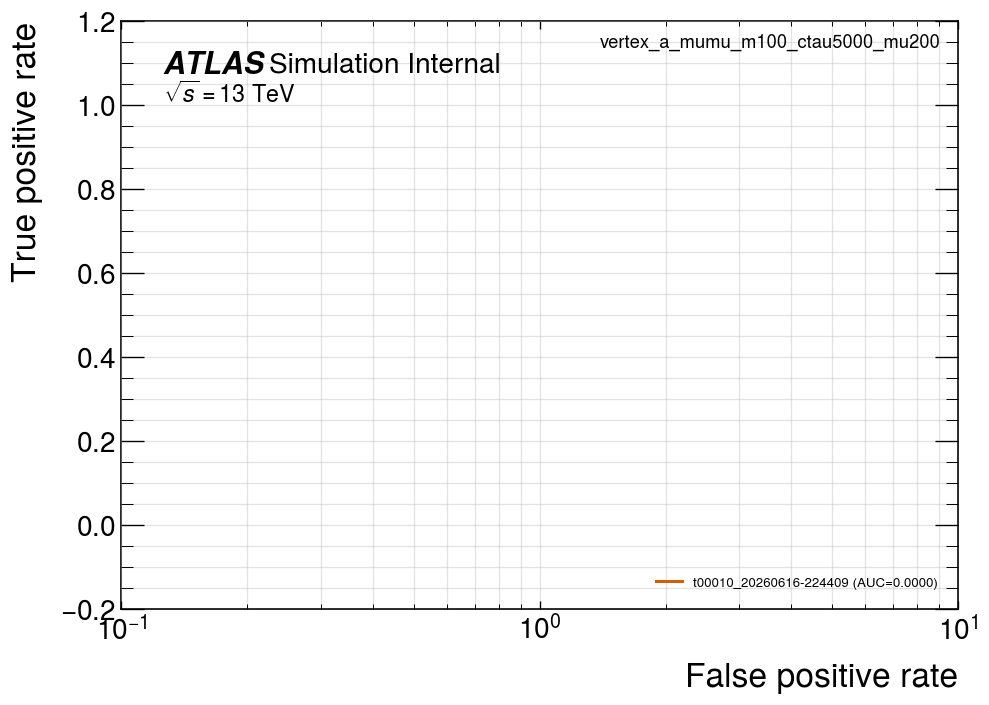

/tmp/ddicroce/ipykernel_2971035/2345241008.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale("log")
/tmp/ddicroce/ipykernel_2971035/2345241008.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left=max(1e-6, ax.get_xlim()[0]), right=1.0)


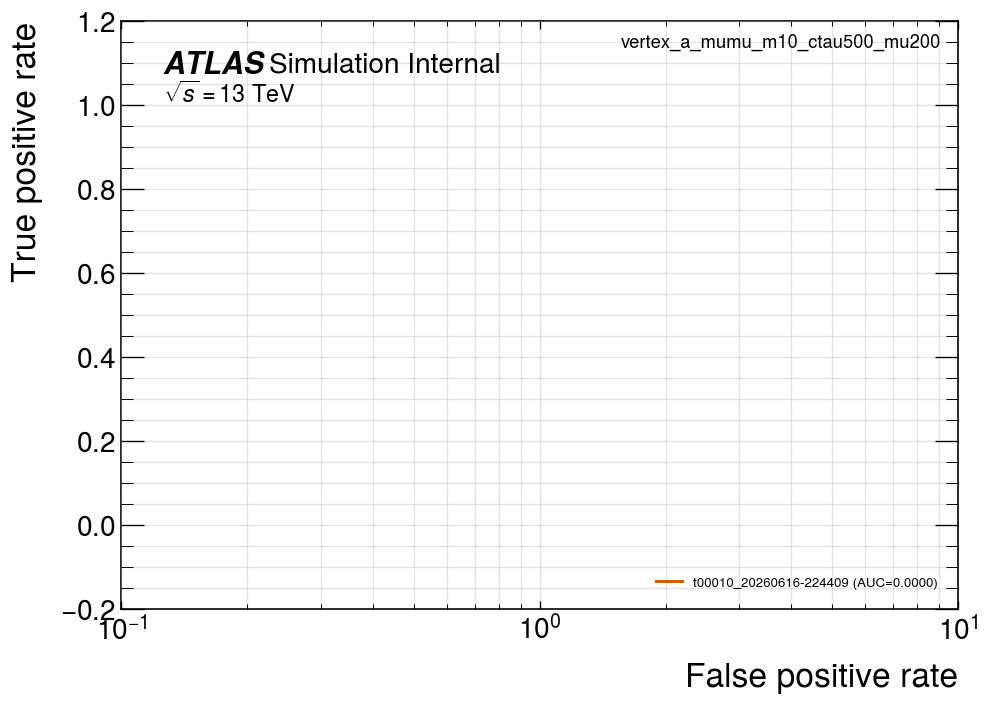

/tmp/ddicroce/ipykernel_2971035/2345241008.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale("log")
/tmp/ddicroce/ipykernel_2971035/2345241008.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left=max(1e-6, ax.get_xlim()[0]), right=1.0)


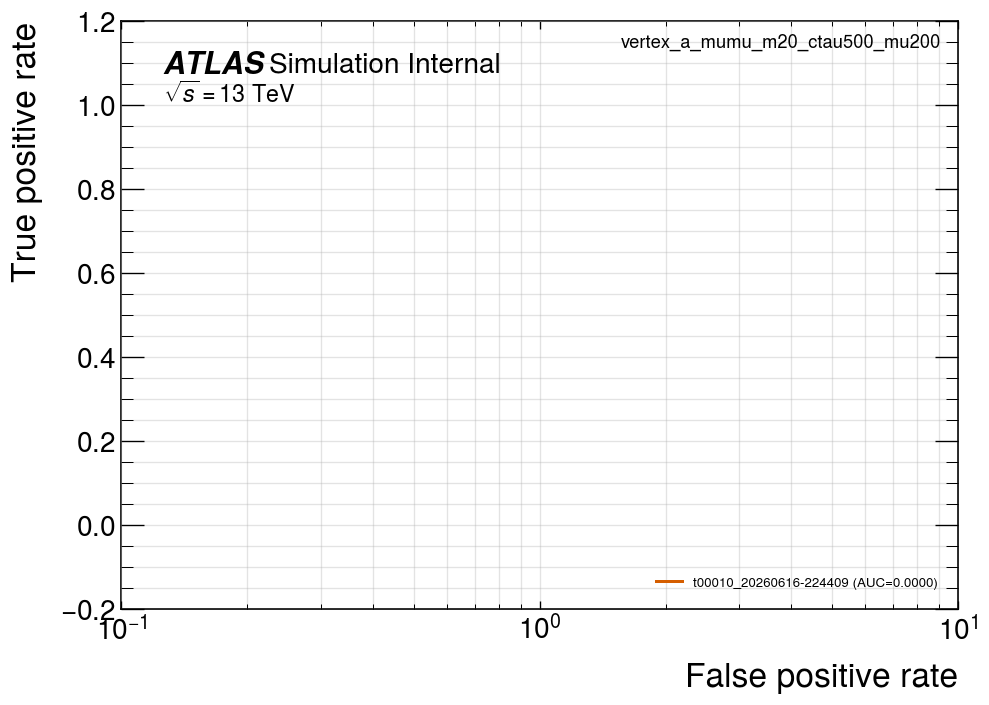

/tmp/ddicroce/ipykernel_2971035/2345241008.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale("log")
/tmp/ddicroce/ipykernel_2971035/2345241008.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left=max(1e-6, ax.get_xlim()[0]), right=1.0)


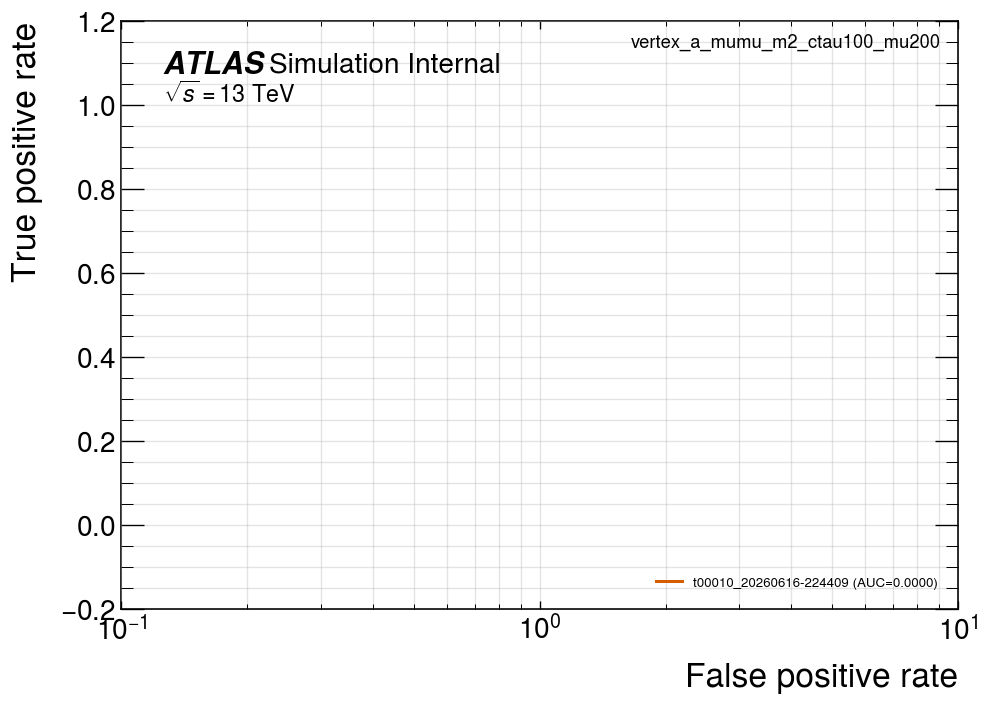

/tmp/ddicroce/ipykernel_2971035/2345241008.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale("log")
/tmp/ddicroce/ipykernel_2971035/2345241008.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left=max(1e-6, ax.get_xlim()[0]), right=1.0)


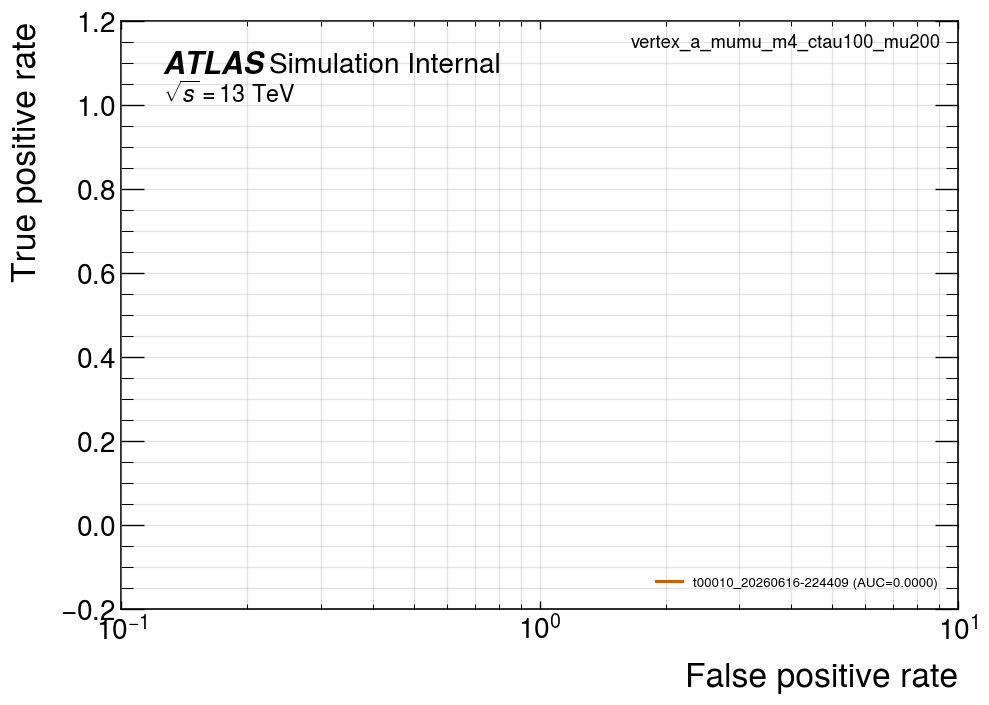

/tmp/ddicroce/ipykernel_2971035/2345241008.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale("log")
/tmp/ddicroce/ipykernel_2971035/2345241008.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left=max(1e-6, ax.get_xlim()[0]), right=1.0)


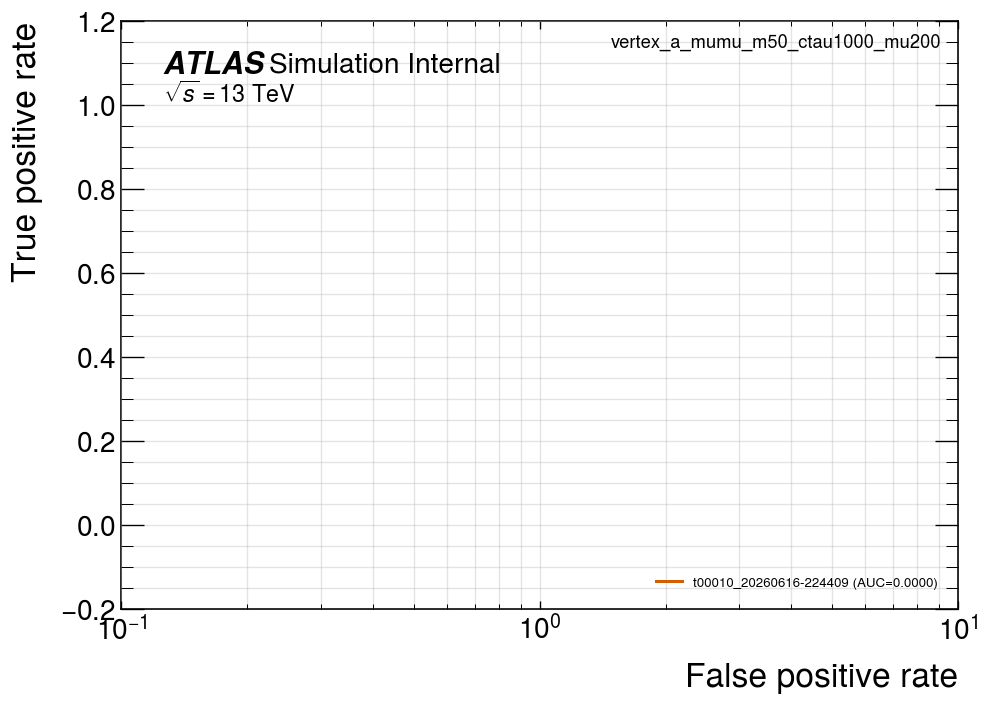

/tmp/ddicroce/ipykernel_2971035/2345241008.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale("log")
/tmp/ddicroce/ipykernel_2971035/2345241008.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left=max(1e-6, ax.get_xlim()[0]), right=1.0)


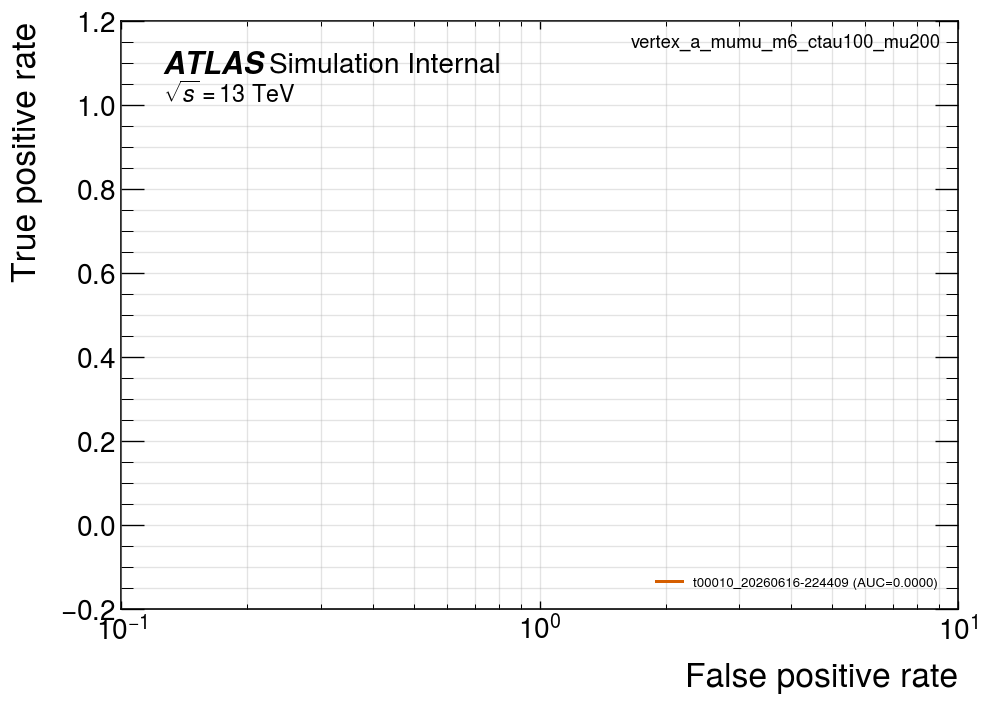

/tmp/ddicroce/ipykernel_2971035/2345241008.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale("log")
/tmp/ddicroce/ipykernel_2971035/2345241008.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left=max(1e-6, ax.get_xlim()[0]), right=1.0)


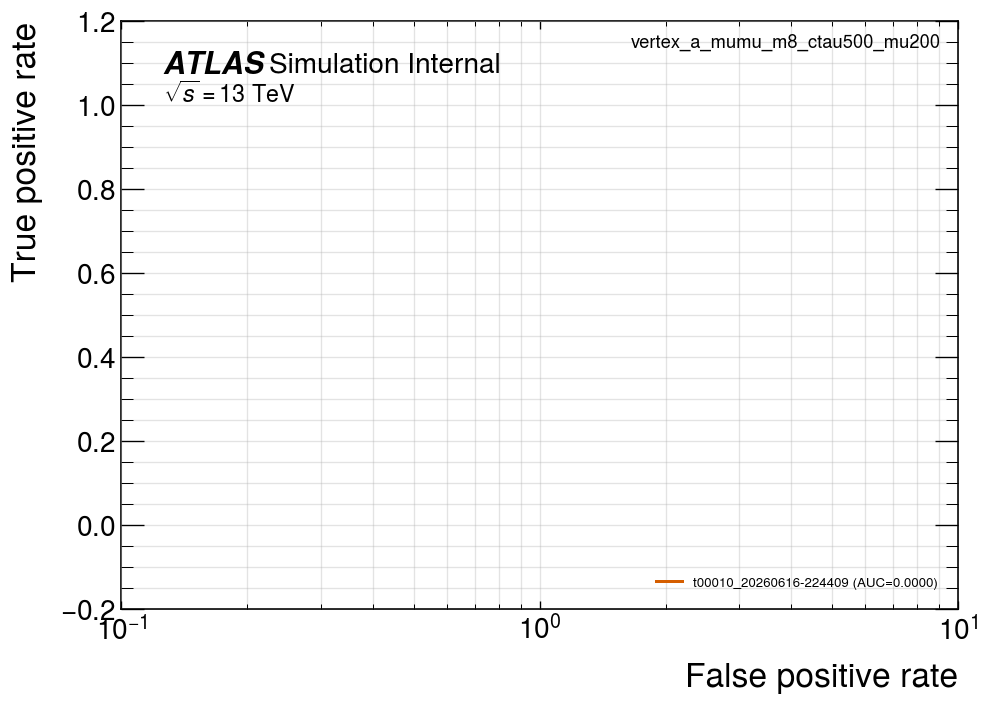

In [19]:
# Per-sample ROC curves for the best model.
for sample in [s for s in best_detail_samples if s != "__all__"]:
    plot_payload_roc(
        [best_entry],
        sample=sample,
        xmode="fpr",
        title=None,
        filename=f"roc_best_{safe_filename(best_name)}_{safe_filename(sample)}.png",
    )


## Model score response

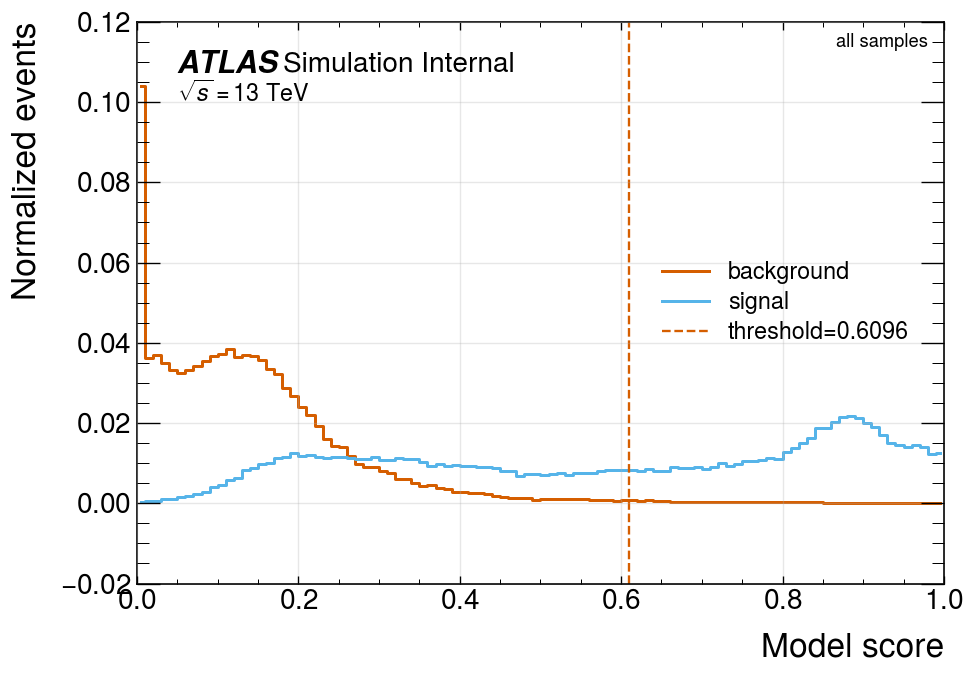

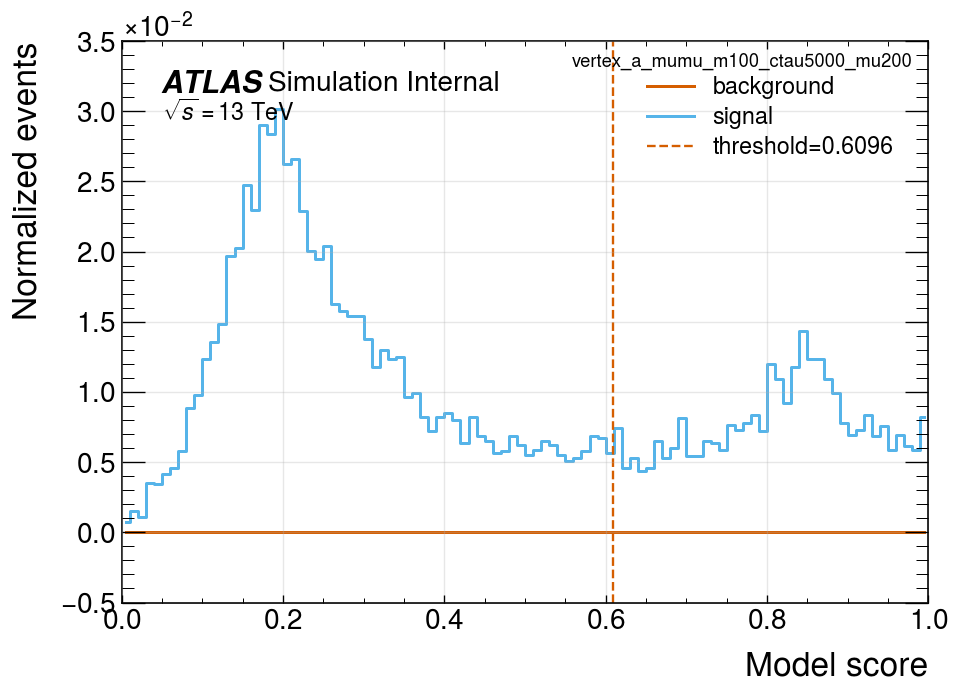

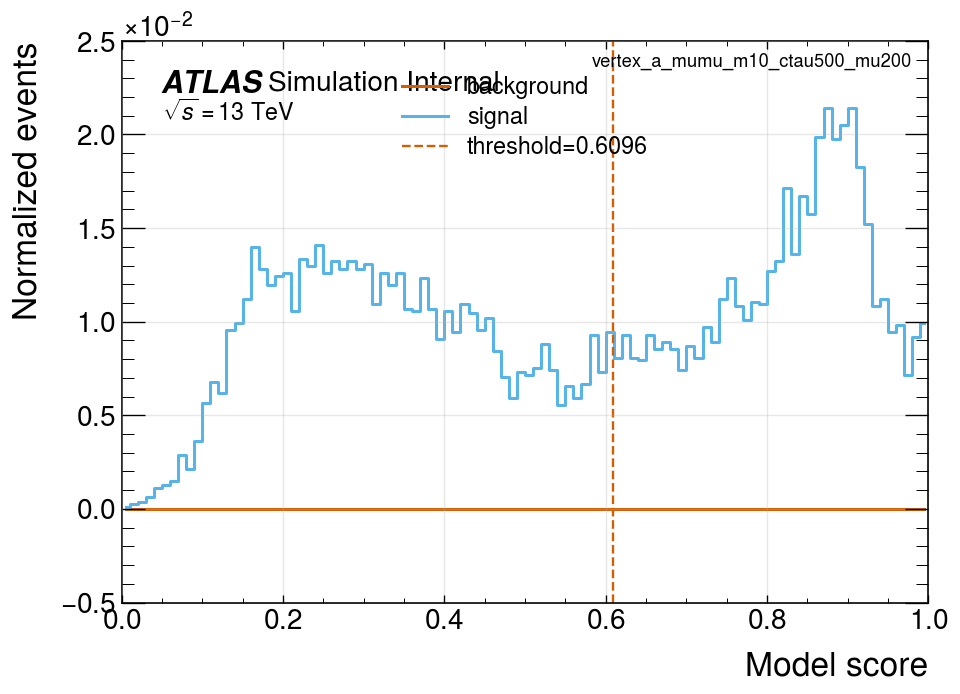

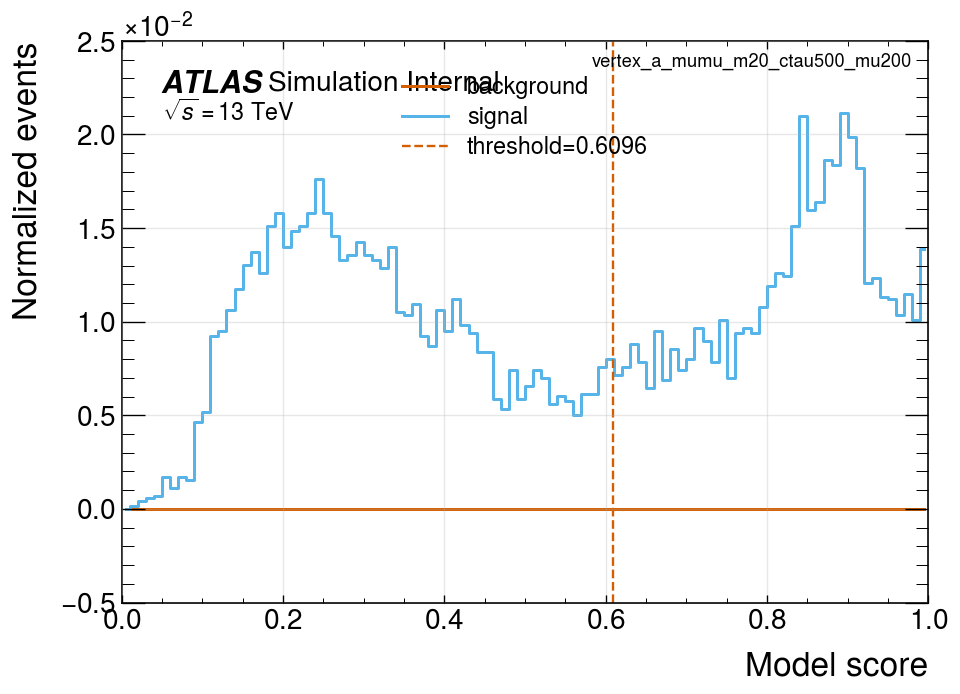

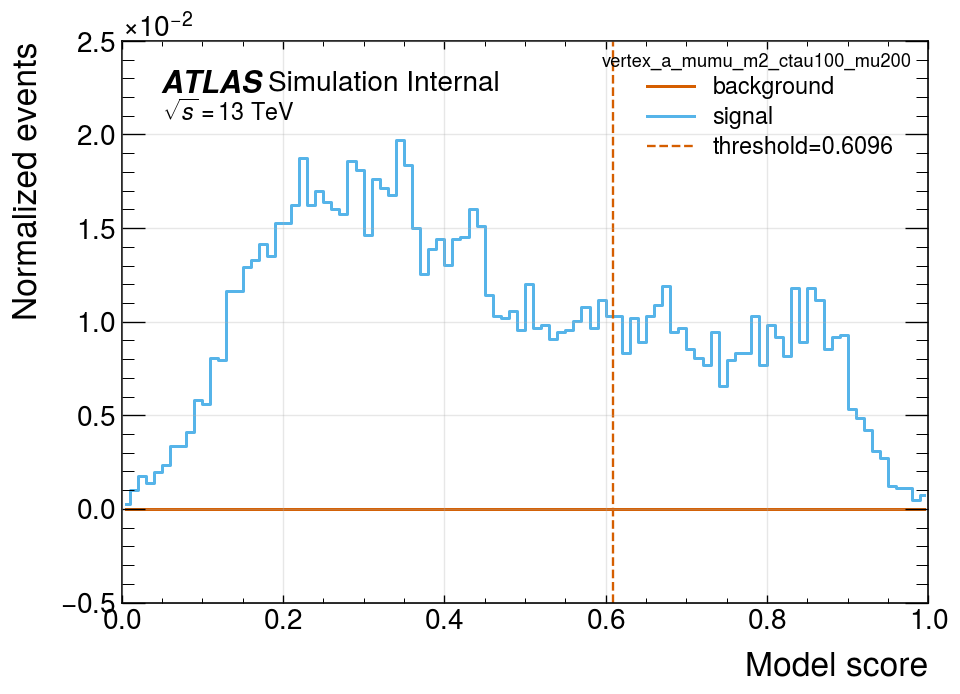

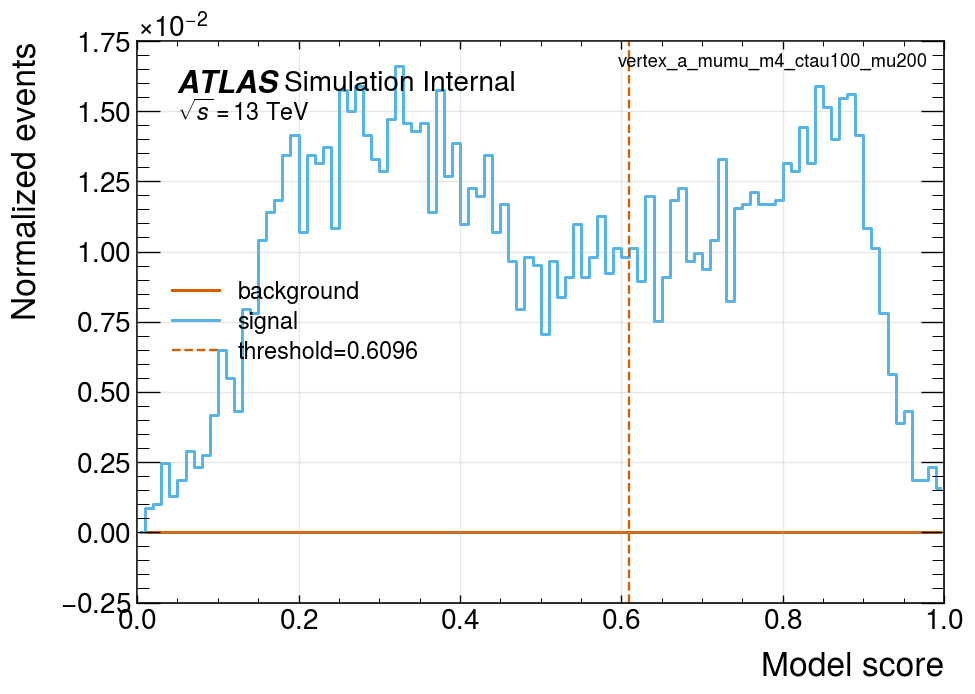

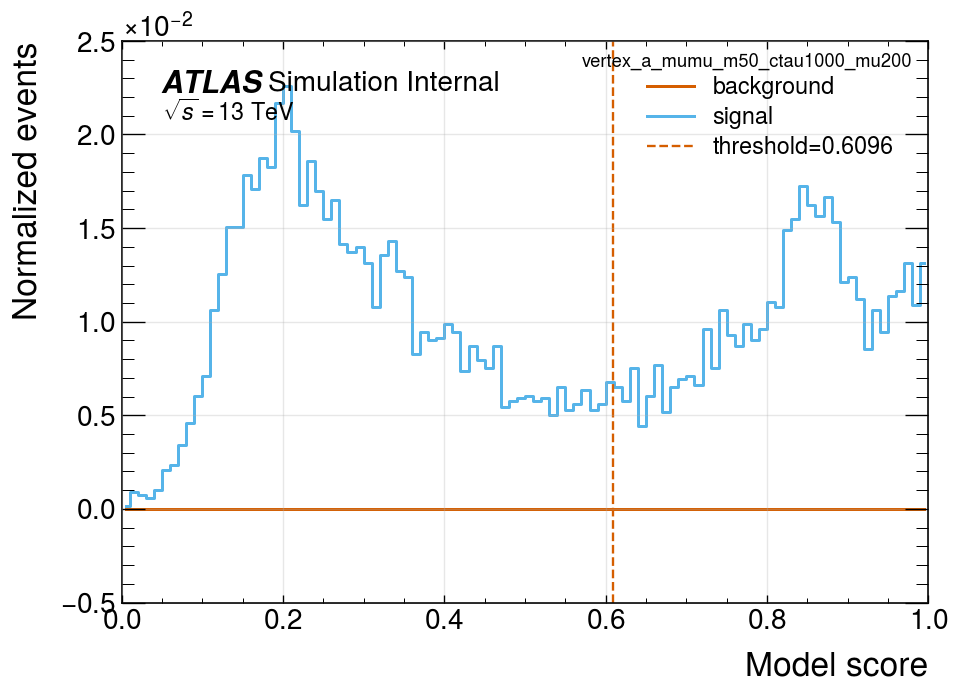

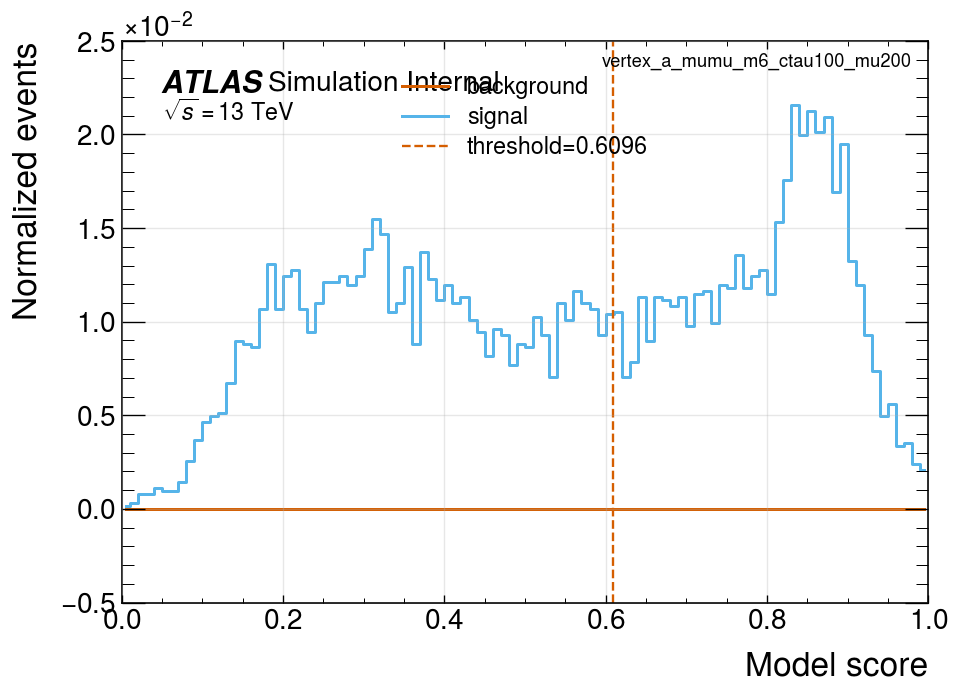

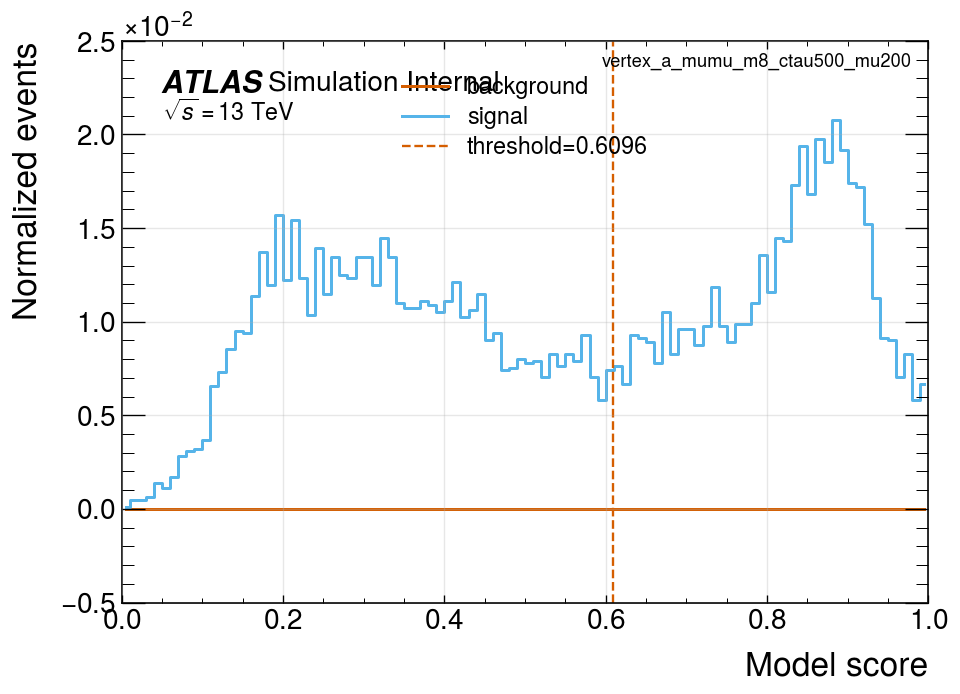

In [20]:
def plot_best_model_score_response(
    entry,
    sample,
    *,
    threshold=None,
    normalize=True,
    n_plot_bins=100,
    filename=None,
    figsize=(8.2, 6.5),
    dpi=120,
):
    sample_payload = entry.get("samples", {}).get(sample)
    if sample_payload is None:
        print(f"Sample {sample!r} not available for {entry.get('plot_name', entry.get('display_name'))}")
        return None, None

    hist = sample_payload.get("histograms", {})
    hist_signal = np.asarray(hist.get("hist_pos", []), dtype=float)
    hist_background = np.asarray(hist.get("hist_neg", []), dtype=float)
    if hist_signal.size == 0 or hist_background.size == 0:
        print(f"No signal/background score histograms found for sample={sample!r}")
        return None, None
    if hist_signal.size != hist_background.size:
        raise ValueError(f"Signal/background histogram sizes differ for sample={sample!r}")

    # Rebin for display.
    n_bins = hist_signal.size
    n_plot_bins = min(int(n_plot_bins), n_bins)
    edges = np.linspace(0.0, 1.0, n_plot_bins + 1)
    old_edges = np.linspace(0.0, 1.0, n_bins + 1)
    old_centers = 0.5 * (old_edges[:-1] + old_edges[1:])
    new_signal = np.zeros(n_plot_bins)
    new_background = np.zeros(n_plot_bins)
    idx = np.clip(np.searchsorted(edges, old_centers, side="right") - 1, 0, n_plot_bins - 1)
    np.add.at(new_signal, idx, hist_signal)
    np.add.at(new_background, idx, hist_background)

    if normalize:
        if new_signal.sum() > 0:
            new_signal = new_signal / new_signal.sum()
        if new_background.sum() > 0:
            new_background = new_background / new_background.sum()

    centers = 0.5 * (edges[:-1] + edges[1:])
    width = edges[1] - edges[0]

    with plot_context():
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        ax.step(centers, new_background, where="mid", label="background", linewidth=1.8)
        ax.step(centers, new_signal, where="mid", label="signal", linewidth=1.8)
        if threshold is not None and np.isfinite(threshold):
            ax.axvline(float(threshold), linestyle="--", linewidth=1.4, label=f"threshold={threshold:.4f}")
        ax.set_xlabel("Model score")
        ax.set_ylabel("Normalized events" if normalize else "Events")
        ax.set_xlim(0.0, 1.0)
        atlas_header(ax, sample_label=pretty_sample_name(sample))
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.subplots_adjust(left=0.14, right=0.96, bottom=0.14, top=0.86)
        if filename:
            save_current_figure(filename)
        return fig, ax

threshold = float(best_row.get("threshold", np.nan))
for sample in best_detail_samples:
    plot_best_model_score_response(
        best_entry,
        sample,
        threshold=threshold,
        filename=f"score_response_{safe_filename(best_name)}_{safe_filename(sample)}.png",
    )


Best model: trial00010_20260616-224409
Best cut: 0.225765
Max S/sqrt(S+B): 267.676483  (S=84590, B=15276)
Saved scan CSV: onnx_eval_compare_displaced_vertex/significance_vs_cut_best_model.csv


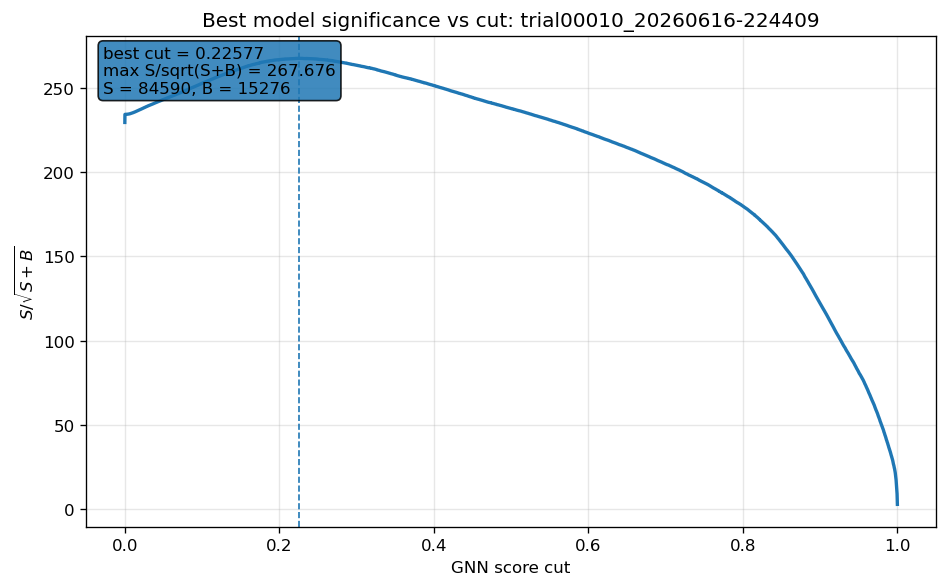

In [21]:
# ============================================================
# Significance vs cut for the best model: S / sqrt(S + B)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the plotting notebook output directory if already defined.
if "output_dir" in globals():
    output_dir = Path(output_dir)
elif "OUTPUT_DIR" in globals():
    output_dir = Path(OUTPUT_DIR)
elif "outdir" in globals():
    output_dir = Path(outdir)
elif "OUTDIR" in globals():
    output_dir = Path(OUTDIR)
else:
    output_dir = Path("onnx_eval_compare_displaced_vertex")

plot_payload_path = output_dir / "plot_payload.pkl"
summary_path = output_dir / "model_summary.csv"

payload = pd.read_pickle(plot_payload_path)
models = list(payload.get("models", []))
if not models:
    raise RuntimeError(f"No models found in {plot_payload_path}")

def _model_auc(model):
    try:
        return float(model["samples"]["__all__"]["roc"]["auc"])
    except Exception:
        return float("nan")

# Pick the best model by model_summary.csv if available; otherwise use payload AUC.
best_model_id = None
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    if "model_id" in summary.columns and "roc_auc" in summary.columns and len(summary):
        best_row = summary.sort_values("roc_auc", ascending=False).iloc[0]
        best_model_id = str(best_row["model_id"])

if best_model_id is not None:
    best_model = next((m for m in models if str(m.get("model_id")) == best_model_id), None)
    if best_model is None:
        best_model = max(models, key=_model_auc)
else:
    best_model = max(models, key=_model_auc)

sample_all = best_model["samples"]["__all__"]

# New payloads contain "significance_scan"; this fallback also works with older payloads.
sig_block = sample_all.get("significance_scan")
if sig_block is not None:
    thresholds = np.asarray(sig_block["thresholds"], dtype=float)
    signal = np.asarray(sig_block["signal"], dtype=float)
    background = np.asarray(sig_block["background"], dtype=float)
    significance = np.asarray(sig_block["significance"], dtype=float)
else:
    hist = sample_all["histograms"]
    hist_pos = np.asarray(hist["hist_pos"], dtype=np.int64)
    hist_neg = np.asarray(hist["hist_neg"], dtype=np.int64)

    thresholds = np.arange(hist_pos.shape[0], dtype=float) / float(hist_pos.shape[0])
    signal = np.cumsum(hist_pos[::-1])[::-1].astype(float)
    background = np.cumsum(hist_neg[::-1])[::-1].astype(float)

    total = signal + background
    significance = np.zeros_like(signal, dtype=float)
    valid = total > 0
    significance[valid] = signal[valid] / np.sqrt(total[valid])

best_idx = int(np.nanargmax(significance))
best_cut = float(thresholds[best_idx])
best_sig = float(significance[best_idx])
best_s = float(signal[best_idx])
best_b = float(background[best_idx])

scan_df = pd.DataFrame({
    "cut": thresholds,
    "signal_pass": signal,
    "background_pass": background,
    "significance_s_over_sqrt_s_plus_b": significance,
})

scan_csv = output_dir / "significance_vs_cut_best_model.csv"
scan_df.to_csv(scan_csv, index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, significance, linewidth=2)
ax.axvline(best_cut, linestyle="--", linewidth=1)

ax.set_xlabel("GNN score cut")
ax.set_ylabel(r"$S/\sqrt{S+B}$")
ax.set_title(f"Best model significance vs cut: {best_model.get('display_name', 'model')}")
ax.grid(True, alpha=0.3)

ax.text(
    0.02, 0.98,
    (
        f"best cut = {best_cut:.5f}\n"
        f"max S/sqrt(S+B) = {best_sig:.3f}\n"
        f"S = {best_s:.0f}, B = {best_b:.0f}"
    ),
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round", "alpha": 0.85},
)

fig.tight_layout()


print(f"Best model: {best_model.get('display_name', best_model.get('model_id', 'model'))}")
print(f"Best cut: {best_cut:.6f}")
print(f"Max S/sqrt(S+B): {best_sig:.6f}  (S={best_s:.0f}, B={best_b:.0f})")
print(f"Saved scan CSV: {scan_csv}")